In [2]:
#Initializing Stuff
import sys
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks, iirnotch
from scipy.optimize import curve_fit
from scipy.ndimage import convolve1d
import pandas as pad
import tkinter as tk
from tkinter import filedialog
import os
sys.path.append( '/Users/Dell/Documents/RESEARCH/tmsi-python-interface-main/tmsi-python-interface-main/TMSiFileFormats/file_readers')
from poly5reader import Poly5Reader



In [ ]:
#Initializing Stuff (If I am on my desktop)
import sys
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks, iirnotch
from scipy.optimize import curve_fit
from scipy.ndimage import convolve1d
import pandas as pad
import tkinter as tk
from tkinter import filedialog
import os
sys.path.append('/Users/Valie/Documents/Electrostim')
from poly5reader import Poly5Reader


In [ ]:
#Get Data   
folder_path = "G:\\My Drive\\Research\\Data\\electrostim_data\\Doug 6-27\\20250627"
root =tk.Tk()
root.withdraw()  # Hide the root window
#select data (studying FLX only)
flexion_data = filedialog.askopenfilename(initialdir=folder_path, title="Select Flexion Data File")
#select baseline data (studying FLX only)
baseline_data = filedialog.askopenfilename(initialdir=folder_path, title="Select Baseline file")


In [ ]:
accel_data_dict = {}

file_path = flexion_data
reader = Poly5Reader(file_path)
    #Extract Raw Samples (Channels x Samples)
samples = reader.samples
ch_names = reader.ch_names
sample_rate = reader.sample_rate
print(reader.ch_names)


trigger_channel = ['TRIGGERS']
trigger_indices = [ch_names.index(name) for name in trigger_channel if name in ch_names]
trigger_samples = samples [trigger_indices, :]
time_axis = np.arange(trigger_samples.shape[1])/ sample_rate


In [ ]:
print(reader.ch_names[73])

In [ ]:
trigger = samples[73,:]
emg = samples[1:65]

grid_order = [
    16, 15, 14, 13, 12, 8, 4, 0,  # Row 1 (17,16,15,14,13, 9, 5, 1)
    21, 20, 19, 18, 17, 9, 5, 1,  # Row 2 (22…2)
    26, 25, 24, 23, 22, 10, 6, 2,  # Row 3
    31, 30, 29, 28, 27, 11, 7, 3,  # Row 4
    32, 33, 34, 35, 36, 52, 56, 60,  # Row 5 (33…61)
    37, 38, 39, 40, 41, 53, 57, 61,  # Row 6
    42, 43, 44, 45, 46, 54, 58, 62,  # Row 7
    47, 48, 49, 50, 51, 55, 59, 63   # Row 8
]

<![alt text](image.png)>

Indexed starting at 0, so channel 30 = channel 31
Channel 17 = 1-1 = R1C1

![alt text](<Screenshot 2025-08-05 113746.png>)

In [ ]:
# 1) Define the grid exactly as above:
grid = [
    [17, 16, 15, 14, 13, 9, 5, 1],
    [22, 21, 20, 19, 18, 10, 6, 2],
    [27, 26, 25, 24, 23, 11, 7, 3],
    [32, 31, 30, 29, 28, 12, 8, 4],
    [33, 34, 35, 36, 37, 53, 57, 61],
    [38, 39, 40, 41, 42, 54, 58, 62],
    [43, 44, 45, 46, 47, 55, 59, 63],
    [48, 49, 50, 51, 52, 56, 60, 64],
]

# 2) Print it nicely:
for r_idx, row in enumerate(grid, start=1):
    print(f"Row {r_idx}:", row)

# 3) Build a channel→(row, col) lookup:
channel_to_pos = {
    ch: (r_idx + 1, c_idx + 1)
    for r_idx, row in enumerate(grid)
    for c_idx, ch in enumerate(row)
}

# Example: what is the position of channel 37?
print("Channel 37 is at R/C:", channel_to_pos[37])


In [ ]:
%matplotlib ipympl
#RAW EMG CHANNELS BEFORE FILTERINGddd

selected_channels = [35, 30, 37]  # Replace with the exact indices you want


# Number of selected channels
num_selected = len(selected_channels)


# Create subplots for each selected channel
fig, axes = plt.subplots(num_selected, 1, sharex=True, figsize=(20, 8))
plt.subplots_adjust(hspace=0.5)

# Loop over the selected channels and plot each one
for ax, ch_idx in zip(axes, selected_channels):
    ax.plot(time_axis, emg[ch_idx], label=f"Channel {ch_idx}")
    ax.set_ylabel("Amplitude (µV)")
    ax.legend(loc="upper right")

# Set common labels and title
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Raw EMG Channels", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
#Smoothing/Bandpass Filtering
def bandpass_filter(x, lowcut, highcut, fs, order=4):
    nyq = fs/2
    b,a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, x)

def lpf_smooth(sig, cutoff, fs, order=5):
    nyq = fs/2
    b,a = butter(order, cutoff/nyq, btype='low')
    if sig.ndim==1:
        return filtfilt(b,a,sig)
    else:
        return np.vstack([filtfilt(b,a,chan) for chan in sig])

In [ ]:
fs          = 2000.0        # sampling rate
lowcut      = 20.0          # band-pass low end (Hz)
highcut     = 450.0         # band-pass high end (Hz)
bp_order    = 4

lpf_cutoff  = 10.0          # envelope smoothing cutoff (Hz)
lpf_order   = 4

In [ ]:

# === 1) BAND-PASS raw EMG ===
# emg: (n_channels, n_samples)


#selected_channels = [0, 30, 32] # Replace with the exact indices you want

filtered = np.zeros_like(emg)
for ch in range(emg.shape[0]):
    filtered[ch, :] = bandpass_filter(emg[ch, :],
                                       lowcut, highcut,
                                       fs, bp_order)

# === 2) LOW-PASS SMOOTH  *filtered* data ===
smoothed = lpf_smooth(filtered, lpf_cutoff, fs, lpf_order)

# === 3) PLOT the SMOOTHED EMG ===
fig, axes = plt.subplots(len(selected_channels), 1,
                         sharex=True, figsize=(12, 6))
plt.subplots_adjust(hspace=0.4)

for ax, ch in zip(axes, selected_channels):
    ax.plot(time_axis, smoothed[ch], color='C0', alpha=0.8)
    ax.set_ylabel(f"Ch {ch} (µV)")
    ax.set_title(f"Channel {ch} Smoothed EMG")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Raw EMG → Band-pass → Low-pass Smoothing", fontsize=16)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [ ]:
# Plot the trigger channel
plt.figure(figsize=(15, 4))
plt.plot(time_axis, trigger, label="Trigger Channel (73)")
plt.xlabel("Time (s)")
plt.ylabel("Trigger Value")
plt.title("Trigger Channel (Index 73)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Find falling edges: trigger goes from 1 to 0
falling_edges = np.where(np.diff(trigger) < -0.5)[0] + 1  # +1 to get the index after the transition

print("Indices where trigger goes from 1 to 0:", falling_edges)

# To get the time between each trigger (in seconds):
falling_times = time_axis[falling_edges]
intervals = np.diff(falling_times)
print("Time between each trigger (s):", intervals)

In [ ]:
#First STA try
# Spike-Triggered Average (STA) using ±50 ms window 

# Parameters
window_ms = 50  # window before and after trigger in ms
window_samples = int(window_ms * sample_rate / 1000)  # samples per side
total_window = 2 * window_samples  # total window size (samples)

# Find trigger events (rising edges)
trigger_diff = np.diff(trigger)
trigger_onsets = np.where(trigger_diff > 0.5)[0] + 1  # adjust for diff offset

# Only keep triggers far enough from start/end for window
valid_triggers = trigger_onsets[
    (trigger_onsets > window_samples) & (trigger_onsets < trigger.shape[0] - window_samples)
]

# Extract EMG snippets around each trigger
snippets = []
for idx in valid_triggers:
    snippet = emg[:, idx - window_samples : idx + window_samples]
    snippets.append(snippet)
snippets = np.stack(snippets, axis=0)  # shape: (n_triggers, n_channels, window)

# Compute average across triggers
sta = np.mean(snippets, axis=0)  # shape: (n_channels, window)

# Time axis for window (centered at trigger)
sta_time = np.linspace(-window_ms, window_ms, total_window)

# Plot STA for selected channels
selected_channels = [0, 30, 32]
plt.figure(figsize=(12, 6))
for ch in selected_channels:
    plt.plot(sta_time, sta[ch], label=f'Ch {ch}')
plt.xlabel('Time (ms) relative to trigger')
plt.ylabel('EMG (µV)')
plt.title('Spike-Triggered Average (±50 ms window)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Spike-Triggered Average (STA) with Baseline Correction (±50 ms window)


# Parameters
window_ms = 50  # window before and after trigger in ms
window_samples = int(window_ms * sample_rate / 1000)  # samples per side, /1000 to convert ms to samples
total_window = 2 * window_samples  # total window size (samples)

# Find trigger events (rising edges)
trigger_diff = np.diff(trigger)
trigger_onsets = np.where(trigger_diff > 0.5)[0] + 1  # adjust for diff offset

# Only keep triggers far enough from start/end for window
valid_triggers = trigger_onsets[
    (trigger_onsets > window_samples) & (trigger_onsets < trigger.shape[0] - window_samples)
]

# Extract and baseline-correct EMG snippets around each trigger
snippets = []
for idx in valid_triggers:
    # raw snippet: shape (n_channels, window)
    snippet = emg[:, idx - window_samples : idx + window_samples]
    # compute baseline from pre-spike portion (first window_samples)
    baseline = np.mean(snippet[:, :window_samples], axis=1, keepdims=True)
    # subtract baseline to center around zero
    snippet_corrected = snippet - baseline
    snippets.append(snippet_corrected)

snippets = np.stack(snippets, axis=0)  # shape: (n_triggers, n_channels, window)

# Compute average across baseline-corrected snippets
sta = np.mean(snippets, axis=0)  # shape: (n_channels, window)

# Time axis for window (centered at trigger)
sta_time = np.linspace(-window_ms, window_ms, total_window)

# Plot STA for selected channels
selected_channels = [35, 30, 37]
plt.figure(figsize=(12, 6))
for ch in selected_channels:
    plt.plot(sta_time, sta[ch], label=f'Ch {ch}')

plt.axvline(0, color='k', linestyle='--', label='Trigger')
plt.xlabel('Time (ms) relative to trigger')
plt.ylabel('Baseline-corrected EMG (µV)')
plt.title('Spike-Triggered Average (±50 ms window)')
plt.legend()
plt.tight_layout()
plt.show()


 ABOVE = M WAVE YAY?

In [ ]:
# Compute peak-to-peak amplitude for each channel in the STA
# sta: shape (n_channels, window)

peak_to_peak = np.ptp(sta, axis=1)  # shape: (n_channels,)

# Example: print or plot for selected channels
for ch in selected_channels:
    print(f"Channel {ch}: Peak-to-peak amplitude = {peak_to_peak[ch]:.2f} µV")

In [ ]:
# Get Data   
folder_path = "G:\\My Drive\\Research\\Data\\electrostim_data\\Doug 6-27"
root = tk.Tk()
root.withdraw()  # Hide the root window

# Select multiple flexion data files
flexion_files = filedialog.askopenfilenames(
    initialdir=folder_path,
    title="Select Flexion Data Files"
)

# Select baseline data (single file)
baseline_data = filedialog.askopenfilename(
    initialdir=folder_path,
    title="Select Baseline file"
 )

# flexion_files will be a tuple of file paths
print("Selected flexion files:", flexion_files)
print("Selected baseline file:", baseline_data)

In [ ]:
# Loop through each selected flexion file
#72 = trigger channel
# aux [3] = iso aux channel
for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    ch_names = reader.ch_names
    sample_rate = reader.sample_rate
    print(f"Loaded: {file_path}")
    print(reader.ch_names)

    # Extract trigger and EMG data
    trigger_channel = ['TRIGGERS']
    trigger_indices = [ch_names.index(name) for name in trigger_channel if name in ch_names]
    trigger_samples = samples[trigger_indices, :]
    time_axis = np.arange(trigger_samples.shape[1]) / sample_rate

    # Example: extract EMG channels (adjust indices as needed) and triggers
    emg = samples[1:65, :]
    aux = samples[66:71, :]  # Assuming aux channels are from 66 to 72
    trigger = samples[72,:]
  
    # processing emg, trigger_samples, etc. for each file

In [ ]:
%matplotlib ipympl  
 # Example: extract EMG channels (adjust indices as needed) and triggers
fig,ax = plt.subplots()
reader = Poly5Reader(flexion_files[0])
samples = reader.samples

emg = samples[1:65, :]
aux = samples[66:71, :]  # Assuming aux channels are from 66 to 72
ax.plot(aux[3,:], label=f"Aux Channel 66 - {os.path.basename(file_path)}")
trigger = samples[72,:]
#ax.plot(trigger[:-100])
plt.show()

In [ ]:
selected_channels = [3, 2, 1]  # Replace with the exact indices you want

for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    ch_names = reader.ch_names
    sample_rate = reader.sample_rate

    # Extract EMG and time axis
    trigger = samples[73,:]
    emg = samples[1:65, :]
    time_axis = np.arange(emg.shape[1]) / sample_rate

    # Plot for this file
    num_selected = len(selected_channels)
    fig, axes = plt.subplots(num_selected, 1, sharex=True, figsize=(20, 8))
    plt.subplots_adjust(hspace=0.5)

    for ax, ch_idx in zip(axes, selected_channels):
        ax.plot(time_axis, emg[ch_idx], label=f"Channel {ch_idx}")
        ax.set_ylabel("Amplitude (µV)")
        ax.legend(loc="upper right")
        ax.set_title(f"Channel {ch_idx}")  # Add title for each subplot

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"Raw EMG Channels - {os.path.basename(file_path)}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [ ]:
#Raw EMG Channels with Spike Artifacts Removal
selected_channels = [35, 30, 37]  # the EMG channel indices you care about

for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples     = reader.samples          # shape: (n_channels, n_samples)
    sample_rate = reader.sample_rate

    # split out trigger & EMG
    trigger = samples[73, :]              # your digital trigger channel
    emg     = samples[1:65, :].astype(float)  # EMG as float for interpolation

    # 1) detect rising‐edge onsets in the trigger
    #    Adjust the threshold if your trigger amplitude changes
    trig_diff = np.diff(trigger)
    onsets    = np.where(trig_diff > 0.5)[0] + 2

    # 2) build a mask of samples to remove around each spike
    #    here we remove 1 sample before and after the detected peak
    mask = np.zeros(emg.shape[1], dtype=bool)
    for idx in onsets:
        # define window of samples to mask
        start = max(idx - 1, 0)
        end   = min(idx + 2, emg.shape[1])  # +2 because slice end is exclusive
        mask[start:end] = True

    # 3) interpolate each channel over the masked samples
    emg_clean = np.zeros_like(emg)
    x = np.arange(emg.shape[1])
    valid = ~mask
    for ch in range(emg.shape[0]):
        y = emg[ch].copy()
        # set spike samples to NaN
        y[mask] = np.nan
        # linear interpolate over NaNs
        emg_clean[ch] = np.interp(x, x[valid], y[valid])

    # now emg_clean has the spike artifacts removed
    # you can plot it or feed it into your bandpass / smoothing pipeline

    # --- quick plot to check channel 35 before & after ---
    import matplotlib.pyplot as plt
    t = x / sample_rate
    plt.figure(figsize=(12,3))
    plt.plot(t, emg[35],    label='raw ch35', alpha=0.5)
    plt.plot(t, emg_clean[35], label='cleaned ch35', linewidth=1)
    plt.legend()
    plt.xlabel('Time (s)'); plt.ylabel('µV')
    plt.title(f"Artifact removal check — {os.path.basename(file_path)}")
    plt.show()

    # …then continue with your usual bandpass, RMS, etc., on emg_clean


    

In [ ]:
def bandpass_filter(x, lowcut, highcut, fs, order=4):
    nyq = fs/2
    b,a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, x)

def lpf_smooth(sig, cutoff, fs, order=5):
    nyq = fs/2
    b,a = butter(order, cutoff/nyq, btype='low')
    if sig.ndim==1:
        return filtfilt(b,a,sig)
    else:
        return np.vstack([filtfilt(b,a,chan) for chan in sig])

def rms_envelope(sig, window_ms, fs):
    """
    Compute the RMS envelope with a moving window of window_ms.
    Works on 1D or 2D (channels × samples) arrays.
    """
    win_samps = int(window_ms * fs / 1000)
    if win_samps < 1:
        raise ValueError("window_ms too small for given fs")
    # squared signal
    if sig.ndim == 1:
        sq = sig**2
        # moving average
        avg_sq = np.convolve(sq, np.ones(win_samps)/win_samps, mode='same')
        return np.sqrt(avg_sq)
    else:
        # for multi‐channel: apply per row
        env = []
        for chan in sig:
            sq = chan**2
            avg_sq = np.convolve(sq, np.ones(win_samps)/win_samps, mode='same')
            env.append(np.sqrt(avg_sq))
        return np.vstack(env)

fs          = 2000.0        # sampling rate
lowcut      = 20.0          # band-pass low end (Hz)
highcut     = 450.0         # band-pass high end (Hz)
bp_order    = 4

lpf_cutoff  = 10.0          # envelope smoothing cutoff (Hz)
lpf_order   = 4

In [ ]:
selected_channels = [35, 30, 37]  # Replace with the exact indices you want

for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    sample_rate = reader.sample_rate
    emg = samples[1:65, :]
    time_axis = np.arange(emg.shape[1]) / sample_rate

    # --- Bandpass filter all EMG channels ---
    filtered = np.zeros_like(emg)
    for ch in range(emg.shape[0]):
        filtered[ch, :] = bandpass_filter(emg[ch, :], lowcut, highcut, sample_rate, bp_order)

    # --- Low-pass smooth all EMG channels ---
    smoothed = lpf_smooth(filtered, lpf_cutoff, sample_rate, lpf_order)

    # --- Plot for selected channels using filtered data ---
    num_selected = len(selected_channels)
    fig, axes = plt.subplots(num_selected, 1, sharex=True, figsize=(20, 8))
    plt.subplots_adjust(hspace=0.5)

    for ax, ch_idx in zip(axes, selected_channels):
        ax.plot(time_axis, filtered[ch_idx], label=f"Channel {ch_idx} (Filtered)")
        ax.set_ylabel("Amplitude (µV)")
        ax.legend(loc="upper right")
        ax.set_title(f"Channel {ch_idx}")

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"Filtered EMG - {os.path.basename(file_path)}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [ ]:
#Smoothed

selected_channels = [35, 30, 37]  # Replace with the exact indices you want

for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    sample_rate = reader.sample_rate
    emg = samples[1:65, :]
    time_axis = np.arange(emg_clean.shape[1]) / sample_rate

    # --- Bandpass filter all EMG channels ---
    filtered = np.zeros_like(emg_clean)
    for ch in range(emg_clean.shape[0]):
        filtered[ch, :] = bandpass_filter(emg_clean[ch, :], lowcut, highcut, sample_rate, bp_order)

    # --- Low-pass smooth all EMG channels ---
    smoothed = lpf_smooth(filtered, lpf_cutoff, sample_rate, lpf_order)

    # --- Plot for selected channels ---
    num_selected = len(selected_channels)
    fig, axes = plt.subplots(num_selected, 1, sharex=True, figsize=(20, 8))
    plt.subplots_adjust(hspace=0.5)

    for ax, ch_idx in zip(axes, selected_channels):
        ax.plot(time_axis, smoothed[ch_idx], label=f"Channel {ch_idx}")
        ax.set_ylabel("Amplitude (µV)")
        ax.legend(loc="upper right")
        ax.set_title(f"Channel {ch_idx}")

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"Filtered & Smoothed EMG - {os.path.basename(file_path)}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [ ]:
#  ONLY Bandpassing RAW EMG data in order to use for STA

selected_channels = [5, 1, 2]  # Replace with the exact indices you want
lpf_cutoff = 20.0  # Low-pass cutoff frequency (Hz)
lpf_order = 4

for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    sample_rate = reader.sample_rate
    emg = samples[1:65, :]  # (n_chan, n_samp)
    time_axis = np.arange(emg.shape[1]) / sample_rate

    # --- Low-pass filter all EMG channels at 20 Hz ---
    emg_lpf = np.zeros_like(emg)
    for ch in range(emg.shape[0]):
        nyq = sample_rate / 2
        b, a = butter(lpf_order, lpf_cutoff / nyq, btype='low')
        emg_lpf[ch, :] = filtfilt(b, a, emg[ch, :])

    # --- Plot for selected channels ---
    num_selected = len(selected_channels)
    fig, axes = plt.subplots(num_selected, 1, sharex=True, figsize=(20, 8))
    plt.subplots_adjust(hspace=0.5)

    for ax, ch_idx in zip(axes, selected_channels):
        ax.plot(time_axis, emg_lpf[ch_idx], label=f"Channel {ch_idx} (Low-pass 20 Hz)")
        ax.set_ylabel("Amplitude (µV)")
        ax.legend(loc="upper right")
        ax.set_title(f"Channel {ch_idx}")

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"Low-pass Filtered EMG (20 Hz) - {os.path.basename(file_path)}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


In [ ]:
#RMS envlope instead of smoothing, better results

selected_channels = [35, 30, 37]  # Replace with the exact indices you want
for file_path in flexion_files:
    reader      = Poly5Reader(file_path)
    samples     = reader.samples
    sample_rate = reader.sample_rate
    emg         = samples[1:65, :]                     # (n_chan, n_samp)
    time_axis   = np.arange(emg_clean.shape[1]) / sample_rate

    # --- 1) Band‑pass filter all EMG channels ---
    filtered = np.zeros_like(emg_clean)
    for ch in range(emg_clean.shape[0]):
        filtered[ch, :] = bandpass_filter(
            emg_clean[ch, :],
            lowcut, highcut,
            sample_rate, bp_order
        )

    # --- 2) Compute 50 ms RMS envelope on each channel ---
    window_ms = 50
    rms_env   = rms_envelope(filtered, window_ms, sample_rate)

    # --- 3) (Optional) Low‑pass smooth the RMS envelope at 10 Hz ---
    rms_smooth = lpf_smooth(rms_env, lpf_cutoff, sample_rate, lpf_order)

    # --- 4) Plot the RMS‐based traces for your selected channels ---
    fig, axes = plt.subplots(len(selected_channels), 1,
                             sharex=True, figsize=(20, 8))
    plt.subplots_adjust(hspace=0.5)

    for ax, ch_idx in zip(axes, selected_channels):
        ax.plot(time_axis, rms_smooth[ch_idx],
                label=f"Channel {ch_idx} RMS")
        ax.set_ylabel("RMS (µV)")
        ax.legend(loc="upper right")
        ax.set_title(f"Channel {ch_idx}")

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"50 ms RMS Envelope – {os.path.basename(file_path)}",
                 fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [ ]:
from sklearn.decomposition import PCA, FastICA

# --- PCA/ICA on RMS envelope (channels x samples) ---
# Transpose to (samples, channels) for decomposition
rms_for_decomp = rms_smooth.T  # shape: (n_samples, n_channels)

# --- PCA ---
pca = PCA(n_components=5)  # Adjust n_components as needed
pca_components = pca.fit_transform(rms_for_decomp)  # shape: (n_samples, n_components)

# --- ICA ---
ica = FastICA(n_components=5, random_state=0)
ica_components = ica.fit_transform(rms_for_decomp)  # shape: (n_samples, n_components)

# --- Plot first 3 PCA components ---
plt.figure(figsize=(12, 6))
for i in range(3):
    plt.plot(time_axis, pca_components[:, i], label=f'PCA Comp {i+1}')
plt.xlabel('Time (s)')
plt.ylabel('Component Value')
plt.title('First 3 PCA Components of RMS HD-EMG')
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot first 3 ICA components ---
plt.figure(figsize=(12, 6))
for i in range(3):
    plt.plot(time_axis, ica_components[:, i], label=f'ICA Comp {i+1}')
plt.xlabel('Time (s)')
plt.ylabel('Component Value')
plt.title('First 3 ICA Components of RMS HD-EMG')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Plot the trigger channel for all selected flexion files
for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    sample_rate = reader.sample_rate
    time_axis = np.arange(samples.shape[1]) / sample_rate
    trigger = samples[72, :-200]

    plt.figure(figsize=(15, 4))
    plt.plot(time_axis[:-200], trigger, label=f"Trigger Channel (72) - {os.path.basename(file_path)}")
    plt.xlabel("Time (s)")
    plt.ylabel("Trigger Value")
    plt.title(f"Trigger Channel (Index 72) - {os.path.basename(file_path)}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    sample_rate = reader.sample_rate
    time_axis = np.arange(samples.shape[1]) / sample_rate
    aux = samples[69, :] #nice

    plt.figure(figsize=(15, 4))
    plt.plot(time_axis, aux, label=f"Trigger Channel (69) - {os.path.basename(file_path)}")
    plt.xlabel("Time (s)")
    plt.ylabel("Trigger Value")
    plt.title(f"Trigger Channel (Index 72) - {os.path.basename(file_path)}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# Function to find peaks in a trigger waveform and convert to current

def trigger_peaks_to_current(trigger, 
                             fs=None, 
                             height=None, 
                             distance=None):
    """
   Find peaks and convert to current shawww
    trigger : array-like
        1D trigger channel (voltages).
    fs : float, optional
        Sampling rate (Hz). If provided, will also return times in seconds.
    height : float or tuple, optional
        Passed to scipy.signal.find_peaks to threshold peak heights.
    distance : int, optional
        Passed to scipy.signal.find_peaks to impose a minimum sample 
        distance between peaks.

    
    peaks_idx : ndarray
        Sample indices of each detected peak.
    times_s : ndarray or None
        Time of each peak in seconds (if fs given), else None.
    volts   : ndarray
        Voltage of each peak.
    currents_mA : ndarray
        Converted current for each peak, in mA.
    """
    # 1) find local maxima in the trigger waveform
    peaks_idx, props = find_peaks(trigger, height=height, distance=distance)

    # 2) peak voltages
    volts = trigger[peaks_idx]

    # 3) apply conversion: 80 mA per 10 V => 8 mA/V
    currents_mA = (80 / 10) * volts

    # optional time vector
    times_s = peaks_idx / fs if fs is not None else None

    return peaks_idx, times_s, volts, currents_mA


# assume `trigger` is your NumPy array and sample_rate is in Hz
idx, t_peak, v_peak, i_peak = trigger_peaks_to_current(
    aux,
    fs=sample_rate,
    height=0.1,     # e.g. only detect peaks above 0.1 V
    distance=100    # e.g. at least 100 samples between peaks
)

for k, (vv, ii) in enumerate(zip(v_peak, i_peak)):
    print(f"Peak #{k:2d}: {vv:.3f} V  →  {ii:.2f} mA")



In [ ]:
print(i_peak)

In [ ]:
# Find falling edges for all selected flexion files
for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    sample_rate = reader.sample_rate
    time_axis = np.arange(samples.shape[1]) / sample_rate
    trigger = samples[73, :]

    # Find falling edges
    falling_edges = np.where(np.diff(trigger) < -0.5)[0] + 1  # +1 to get the index after the transition
    print(f"\nFile: {os.path.basename(file_path)}")
    print("Indices where trigger goes from 1 to 0:", falling_edges)

    # Time between each trigger (in seconds)
    falling_times = time_axis[falling_edges]
    intervals = np.diff(falling_times)
    print("Time between each trigger (s):", intervals)

In [ ]:
# how much of the snippet you want around each spike
#interpolate then smush the parts together
sta_window_ms = 50    # ±200 ms for STA
blank_ms      = 4      # only exclude ±4 ms around t=0

selected_channels = [2, 5, 1]

for file_path in flexion_files:
    reader      = Poly5Reader(file_path)
    samples     = reader.samples
    sample_rate = reader.sample_rate

    emg     = samples[1:65, :]
    trigger = samples[72, :]

    # compute how many samples for each window
    sta_window_samps = int(sta_window_ms * sample_rate / 1000)
    total_window     = 2 * sta_window_samps

    # find valid trigger indices
    trigger_diff   = np.diff(trigger)
    trigger_onsets = np.where(trigger_diff > 0.5)[0] + 1
    valid_triggers = trigger_onsets[
        (trigger_onsets > sta_window_samps) &
        (trigger_onsets < trigger.shape[0] - sta_window_samps)
    ]

    # collect baseline-corrected snippets
    snippets = []
    for idx in valid_triggers:
        snippet  = emg[:, idx - sta_window_samps : idx + sta_window_samps]
        baseline = snippet[:, :sta_window_samps].mean(axis=1, keepdims=True)
        snippets.append(snippet - baseline)

    if not snippets:
        print(f"No valid triggers in {os.path.basename(file_path)}")
        continue

    # stack into shape (n_trigs, n_ch, n_time)
    snips = np.stack(snippets, axis=0).astype(float)

    # build a time‐axis centered on t=0
    sta_time = np.linspace(-sta_window_ms, sta_window_ms, total_window)

    # 1D boolean mask over time: True inside ±blank_ms
    time_mask = np.abs(sta_time) <= blank_ms  # shape: (total_window,)

    # … everything up through stacking your snippets …
snips = np.stack(snippets, axis=0).astype(float)    # shape: (n_trigs, n_ch, total_window)

# build a 1-D boolean mask over time
sta_time  = np.linspace(-sta_window_ms, sta_window_ms, total_window)
time_mask = np.abs(sta_time) <= blank_ms            # shape: (total_window,)

# manually broadcast to full shape
mask_full = np.broadcast_to(time_mask[None, None, :], snips.shape)
# now create a masked array with the exact same shape
snips_ma  = np.ma.array(snips, mask=mask_full)

# compute STA ignoring the masked region
sta = snips_ma.mean(axis=0).filled(np.nan)         # shape: (n_ch, total_window)

# plotting
plt.figure(figsize=(15,18))
for ch in selected_channels:
    plt.plot(sta_time, sta[ch], label=f'Ch {ch}')
plt.axvline(0, color='k', linestyle='--', label='Trigger')
plt.xlabel('Time (ms) relative to trigger')
plt.ylabel('Baseline-corrected EMG (µV)')
plt.title(f'STA ±{sta_window_ms} ms, excl. ±{blank_ms} ms\n'
          f'{os.path.basename(file_path)}')
plt.legend()
plt.tight_layout()
plt.show()





In [ ]:
%matplotlib ipympl
# how much of the snippet you want around each spike
sta_window_ms = 200    # ±200 ms for STA
blank_ms      = 4      # interpolate ±4 ms around t=0

selected_channels = [2, 5, 1]

for file_path in flexion_files:
    reader      = Poly5Reader(file_path)
    samples     = reader.samples
    sample_rate = reader.sample_rate

    emg     = samples[1:65, :]
    trigger = samples[72, :]

    # compute how many samples for each window
    sta_window_samps = int(sta_window_ms * sample_rate / 1000)
    total_window     = 2 * sta_window_samps

    # find valid trigger indices
    trigger_diff   = np.diff(trigger)
    trigger_onsets = np.where(trigger_diff > 0.5)[0] + 1
    valid_triggers = trigger_onsets[
        (trigger_onsets > sta_window_samps) &
        (trigger_onsets < trigger.shape[0] - sta_window_samps)
    ]

    # collect baseline-corrected snippets
    snippets = []
    for idx in valid_triggers:
        snippet  = emg[:, idx - sta_window_samps : idx + sta_window_samps]
        baseline = snippet[:, :sta_window_samps].mean(axis=1, keepdims=True)
        snippets.append(snippet - baseline)

    if not snippets:
        print(f"No valid triggers in {os.path.basename(file_path)}")
        continue

    # stack into shape (n_trigs, n_ch, n_time)
    snips = np.stack(snippets, axis=0).astype(float)

    # compute STA normally (no masking here)
    sta = snips.mean(axis=0)  # shape: (n_ch, total_window)

    # build a time‐axis centered on t=0
    sta_time = np.linspace(-sta_window_ms, sta_window_ms, total_window)

    # find the sample-indices bounding the ±blank_ms region
    # we pick the last index <= -blank_ms, and the first >= +blank_ms
    neg_idx = np.where(sta_time <= -blank_ms)[0][-1]
    pos_idx = np.where(sta_time >=  blank_ms)[0][0]

    # now create a copy and interpolate between those two edge-points
    sta_filled = sta.copy()
    for ch in selected_channels:
        y0 = sta[ch, neg_idx]
        y1 = sta[ch, pos_idx]
        # linear ramp from y0→y1 over the blank interval
        sta_filled[ch, neg_idx:pos_idx+1] = np.linspace(y0, y1, pos_idx - neg_idx + 1)

    # plotting
    plt.figure(figsize=(15,9))
    for ch in selected_channels:
        plt.plot(sta_time, sta_filled[ch], label=f'Ch {ch}')
    plt.axvline(0, color='k', linestyle='--', label='Trigger (blank + interpolate)')
    plt.xlabel('Time (ms) relative to trigger')
    plt.ylabel('Baseline-corrected EMG (µV)')
    plt.title(f'STA ±{sta_window_ms} ms with ±{blank_ms} ms interpolated\n{os.path.basename(file_path)}')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
# how much of the snippet you want around each spike
sta_window_ms = 200    # ±200 ms for STA
blank_ms      = 4      # interpolate ±4 ms around t=0

# windows for M and H latencies
m_window = (5,  15)    # in ms
h_window = (15, 35)    # in ms

selected_channels = [2, 5, 1]

for file_path in flexion_files:
    reader      = Poly5Reader(file_path)
    samples     = reader.samples
    sample_rate = reader.sample_rate

    emg     = samples[1:65, :]
    trigger = samples[72, :]

    # compute how many samples for each window
    sta_window_samps = int(sta_window_ms * sample_rate / 1000)
    total_window     = 2 * sta_window_samps

    # find valid trigger indices
    trigger_diff   = np.diff(trigger)
    trigger_onsets = np.where(trigger_diff > 0.5)[0] + 1
    valid_triggers = trigger_onsets[
        (trigger_onsets > sta_window_samps) &
        (trigger_onsets < trigger.shape[0] - sta_window_samps)
    ]

    # collect baseline-corrected snippets
    snippets = []
    for idx in valid_triggers:
        snippet  = emg[:, idx - sta_window_samps : idx + sta_window_samps]
        baseline = snippet[:, :sta_window_samps].mean(axis=1, keepdims=True)
        snippets.append(snippet - baseline)

    if not snippets:
        print(f"No valid triggers in {os.path.basename(file_path)}")
        continue

    # stack and compute STA
    snips = np.stack(snippets, axis=0).astype(float)
    sta   = snips.mean(axis=0)  # shape: (n_ch, total_window)

    # build a time‐axis centered on t=0
    sta_time = np.linspace(-sta_window_ms, sta_window_ms, total_window)

    # locate the indices bounding the ±blank_ms region
    neg_idx = np.where(sta_time <= -blank_ms)[0][-1]
    pos_idx = np.where(sta_time >=  blank_ms)[0][0]

    # interpolate across ±blank_ms
    sta_filled = sta.copy()
    for ch in selected_channels:
        y0 = sta[ch, neg_idx]
        y1 = sta[ch, pos_idx]
        sta_filled[ch, neg_idx:pos_idx+1] = np.linspace(y0, y1, pos_idx - neg_idx + 1)

    # now compute M‐ and H‐peak latencies for each channel
    m_times = {}
    h_times = {}
    # find sample‐ranges for those windows
    m_idx_range = np.where((sta_time >= m_window[0]) & (sta_time <= m_window[1]))[0]
    h_idx_range = np.where((sta_time >= h_window[0]) & (sta_time <= h_window[1]))[0]

    for ch in selected_channels:
        # within each window, pick the sample with largest absolute deflection
        m_peak_rel = np.argmax(np.abs(sta_filled[ch, m_idx_range]))
        h_peak_rel = np.argmax(np.abs(sta_filled[ch, h_idx_range]))

        # map back to global index and then to time
        m_idx = m_idx_range[m_peak_rel]
        h_idx = h_idx_range[h_peak_rel]

        m_times[ch] = sta_time[m_idx]
        h_times[ch] = sta_time[h_idx]

    # printing your latencies
    print(f"\n{os.path.basename(file_path)}:")
    for ch in selected_channels:
        print(f"  Ch {ch}: M-wave @ {m_times[ch]:.1f} ms, H-wave @ {h_times[ch]:.1f} ms")

    # plotting
    plt.figure(figsize=(12,6))
    for ch in selected_channels:
        plt.plot(sta_time, sta_filled[ch], label=f'Ch {ch}')
        # mark the peaks
        plt.plot([m_times[ch]], [sta_filled[ch, m_idx]],
                 'o', color='k', markersize=5)
        plt.plot([h_times[ch]], [sta_filled[ch, h_idx]],
                 's', color='k', markersize=5)

    plt.axvline(0, color='k', linestyle='--', label='Trigger (blank + interp)')
    plt.xlabel('Time (ms) relative to trigger')
    plt.ylabel('Baseline-corrected EMG (µV)')
    plt.title(f'STA ±{sta_window_ms} ms, interp ±{blank_ms} ms\n'
              f'{os.path.basename(file_path)}')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
print("sta.shape:", sta.shape, "sta_time.shape:", sta_time.shape)



In [ ]:
# Compute peak-to-peak amplitude for each channel in the STA for all flexion_files

window_ms = 50  # window before and after trigger in ms
selected_channels = [2, 5, 1]  
all_peak_to_peak = {}
for file_path in flexion_files:
    
    reader = Poly5Reader(file_path)
    samples = reader.samples
    sample_rate = reader.sample_rate  

    emg = samples[1:65, :]
    trigger = samples[72, :]
    window_samples = int(window_ms * sample_rate / 1000)
    total_window = 2 * window_samples

    # Find trigger events (rising edges)
    trigger_diff = np.diff(trigger)
    trigger_onsets = np.where(trigger_diff > 0.5)[0] + 1

    # Only keep triggers far enough from start/end for window
    valid_triggers = trigger_onsets[
        (trigger_onsets > window_samples) & (trigger_onsets < trigger.shape[0] - window_samples)
    ]

    # Extract and baseline-correct EMG snippets around each trigger
    snippets = []
    for idx in valid_triggers:
        snippet = emg[:, idx - window_samples : idx + window_samples]
        baseline = np.mean(snippet[:, :window_samples], axis=1, keepdims=True)
        snippet_corrected = snippet - baseline
        snippets.append(snippet_corrected)

    if len(snippets) == 0:
        print(f"No valid triggers found in {os.path.basename(file_path)}")
        continue

    snippets = np.stack(snippets, axis=0)  # shape: (n_triggers, n_channels, window)
    sta = np.mean(snippets, axis=0)  # shape: (n_channels, window)

    # Compute peak-to-peak amplitude for each channel in the STA
    peak_to_peak = np.ptp(sta, axis=1)  # shape: (n_channels,)
    all_peak_to_peak[os.path.basename(file_path)] = peak_to_peak

    # Print results for selected channels
    print(f"\nFile: {os.path.basename(file_path)}")
    for ch in selected_channels:
        print(f"  Channel {ch}: Peak-to-peak amplitude = {peak_to_peak[ch]:.2f} µV")

In [ ]:
# define your M‐ and H‐wave windows in ms (relative to the trigger)
m_window_ms = (6, 10)    # M‐wave from +6 to +10 ms
h_window_ms = (25, 35)   # H‐wave from +25 to +35 ms

window_ms = 50           # your full STA window
selected_channels = [2, 5, 1]
all_peak_to_peak = {}

for file_path in flexion_files:
    reader      = Poly5Reader(file_path)
    samples     = reader.samples
    sample_rate = reader.sample_rate

    emg     = samples[1:65, :]
    trigger = samples[72, :]

    # compute sample counts
    window_samps  = int(window_ms * sample_rate / 1000)
    total_window  = 2 * window_samps
    sta_time      = np.linspace(-window_ms, window_ms, total_window)

    # find triggers
    trigger_onsets = np.where(np.diff(trigger) > 0.5)[0] + 1
    valid_triggers = trigger_onsets[
        (trigger_onsets > window_samps) &
        (trigger_onsets < trigger.shape[0] - window_samps)
    ]

    # collect snippets and compute STA
    snippets = []
    for idx in valid_triggers:
        snip     = emg[:, idx - window_samps : idx + window_samps]
        baseline = snip[:, :window_samps].mean(axis=1, keepdims=True)
        snippets.append(snip - baseline)
    if not snippets:
        print(f"No valid triggers in {os.path.basename(file_path)}")
        continue
    sta = np.mean(np.stack(snippets, axis=0), axis=0)  # (n_ch, total_window)

    # find index ranges for M and H windows
    m_idx = np.where((sta_time >= m_window_ms[0]) & (sta_time <= m_window_ms[1]))[0]
    h_idx = np.where((sta_time >= h_window_ms[0]) & (sta_time <= h_window_ms[1]))[0]

    # compute p-to-p in each window
    m_ptp = np.ptp(sta[:, m_idx], axis=1)  # (n_ch,)
    h_ptp = np.ptp(sta[:, h_idx], axis=1)  # (n_ch,)

    all_peak_to_peak[os.path.basename(file_path)] = {
        'M-wave (6–10 ms)': m_ptp,
        'H-wave (25–35 ms)': h_ptp
    }

    # print only your selected channels
    print(f"\nFile: {os.path.basename(file_path)}")
    for ch in selected_channels:
        print(f"  Ch {ch} | M-wave p2p = {m_ptp[ch]:.1f} µV, "
              f"H-wave p2p = {h_ptp[ch]:.1f} µV")


In [ ]:
#Higest peak-to-peak amplitude across all files - does not account for SNR/Impedance
window_ms = 4  # window before and after trigger in ms
all_peak_to_peak = {}

for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples     = reader.samples
    sample_rate = reader.sample_rate  

    emg     = samples[1:65, :]   # assume channels 1–64 are EMG
    trigger = samples[72, :]
    window_samples = int(window_ms * sample_rate / 1000)

    # 1) Find trigger onsets
    trigger_diff   = np.diff(trigger)
    trigger_onsets = np.where(trigger_diff > 0.5)[0] + 1

    # 2) Keep only onsets far enough from edges
    valid_triggers = trigger_onsets[
        (trigger_onsets > window_samples) &
        (trigger_onsets < trigger.shape[0] - window_samples)
    ]

    snippets = []
    for idx in valid_triggers:
        snippet = emg[:, idx - window_samples : idx + window_samples]
        baseline = np.mean(snippet[:, :window_samples], axis=1, keepdims=True)
        snippets.append(snippet - baseline)

    if not snippets:
        print(f"No valid triggers in {os.path.basename(file_path)}")
        continue

    snippets = np.stack(snippets, axis=0)  # (n_triggers, n_channels, window)
    sta      = np.mean(snippets, axis=0)   # (n_channels, window)

    # 3) Peak-to-peak for every channel
    peak_to_peak = np.ptp(sta, axis=1)     # length = n_channels
    all_peak_to_peak[os.path.basename(file_path)] = peak_to_peak

    # 4) Find the “best” channel
    best_ch   = int(np.argmax(peak_to_peak))
    best_val  = peak_to_peak[best_ch]

    # 5) Print summary
    print(f"\nFile: {os.path.basename(file_path)}")
    print(f"  Best channel → #{best_ch} with {best_val:.2f} µV pp-amp")

    # (Optional) If you still want to see all channels’ values:
    # for ch, val in enumerate(peak_to_peak):
    #     print(f"    Ch {ch:2d}: {val:.2f} µV")


In [ ]:

#How I pikc best channel to use for further analysis
#background emg during rest, rms rest histogram within 1s window
import os
import numpy as np
from scipy.signal import find_peaks

window_ms = 50
all_peak_to_peak = {}
all_baseline_rms = {}

for file_path in flexion_files:
    reader      = Poly5Reader(file_path)
    samples     = reader.samples
    fs          = reader.sample_rate
    emg         = samples[1:65, :]   # channels × time
    trigger     = samples[72, :]
    win_samps   = int(window_ms * fs / 1000)

    # --- find triggers & build STA ---
    diffs    = np.diff(trigger)
    onsets   = np.where(diffs > 0.5)[0] + 1
    valid    = onsets[(onsets>win_samps)&(onsets<emg.shape[1]-win_samps)]
    snippets = []
    for idx in valid:
        snip     = emg[:, idx-win_samps:idx+win_samps]
        baseline = snip[:, :win_samps].mean(axis=1, keepdims=True)
        snippets.append(snip - baseline)
    if not snippets:
        continue
    sta = np.mean(np.stack(snippets), axis=0)  # (channels, window)

    # --- 1) peak-to-peak of STA ---
    ptp       = np.ptp(sta, axis=1)            # (channels,)
    all_peak_to_peak[os.path.basename(file_path)] = ptp

    # --- 2) baseline RMS as noise proxy ---
    first_trig = valid[0]
    noise_win  = int(0.100 * fs)  # 100 ms
    noise_seg  = emg[:, first_trig-noise_win : first_trig]
    rms_noise  = np.sqrt(np.mean(noise_seg**2, axis=1))  # (channels,)
    all_baseline_rms[os.path.basename(file_path)] = rms_noise

  # 3) combined score and top-3 channels, excluding NaNs
score = ptp / rms_noise   # shape (n_channels,)

# create a boolean mask of finite scores
valid_mask = np.isfinite(score)

# get indices of channels with valid scores
valid_chs = np.where(valid_mask)[0]

# sort only the valid scores in descending order
sorted_valid = valid_chs[np.argsort(score[valid_mask])[::-1]]

# pick top 4 (channel 3 = outlier??)
top4 = sorted_valid[:4]

# 4 summary
print(f"\nFile: {os.path.basename(file_path)}")
print("→ Top 3 channels by (ptp ÷ baseline RMS):")
for rank, ch in enumerate(top4, start=1):
    print(f"   {rank}. Channel {ch} — score {score[ch]:.2f}, ptp {ptp[ch]:.1f} µV, rms {rms_noise[ch]:.1f} µV")





In [ ]:

baseline_samples = int(0.005 * sample_rate)  # use 5 ms pre-stim for noise

snr = []
for ch in range(sta.shape[0]):
    # 1) signal = peak-to-peak in the post-stimulus STA
    sig = np.ptp(sta[ch, :])
    # 2) noise = baseline standard deviation
    noise = np.std(sta[ch, :baseline_samples])
    snr.append(sig / noise if noise > 0 else 0)

snr = np.array(snr)

# find the top 3 channels by SNR
top3_idx = np.argsort(snr)[::-1][:3]  # descending sort, take first 3

print("→ Top 3 channels by SNR:")
for rank, ch in enumerate(top3_idx, start=1):
    print(f"   {rank}. Channel {ch} (SNR = {snr[ch]:.1f})")


In [ ]:
# ——— 1) Helper function ——— #narrow window
#separate m > h, then plot recruit separately
def trigger_peaks_to_current(trigger, fs=None, height=None, distance=None):
    peaks_idx, props = find_peaks(trigger, height=height, distance=distance)
    volts    = trigger[peaks_idx]
    currents = (80/10) * volts
    times_s  = peaks_idx / fs if fs is not None else None
    return peaks_idx, times_s, volts, currents

# ——— 2) User settings ———
channel_to_plot = 5     # ← set this to the channel you want to visualize
win_start_ms    = 6       # window start (ms) after pulse artifact
win_end_ms      = 30      # window end (ms) after pulse artifact

# ——— 3) Load data ———
# reader       = Poly5Reader(filename)
# aux          = reader.samples[trigger_channel_index]
# emg          = reader.samples[1:65, :]      # shape (n_channels, n_samples)
# sample_rate  = reader.sample_rate

# ——— 4) Detect pulses & convert ———
peaks_idx, times_s, v_peak, i_peak = trigger_peaks_to_current(
    aux, fs=sample_rate, height=0.1, distance=100
)

# ——— 5) Extract per-pulse EMG response for one channel ———
win_start = int(win_start_ms * sample_rate / 1000)
win_end   = int(win_end_ms   * sample_rate / 1000)

emg_resp = []
for idx in peaks_idx:
    seg = emg[channel_to_plot, idx + win_start : idx + win_end]
    emg_resp.append(np.ptp(seg))
emg_resp = np.array(emg_resp)


print(f"Plotting recruitment curve for Channel {channel_to_plot}")

# ——— 6) Build & plotting  recruitment curve ———
pairs = sorted(zip(i_peak, emg_resp), key=lambda x: x[0])
I_sorted, R_sorted = zip(*pairs)

plt.figure(figsize=(15,12))
plt.plot(I_sorted, R_sorted, 'o-', linewidth=2, markersize=6)
plt.xlabel('Stim current (mA)')
plt.ylabel(f'EMG pp amp (µV) — Channel {channel_to_plot}')
plt.title(f'Recruitment Curve — Channel {channel_to_plot}')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.signal import find_peaks

def trigger_peaks_to_current(trigger, fs=None, height=None, distance=None):
    peaks_idx, props = find_peaks(trigger, height=height, distance=distance)
    volts    = trigger[peaks_idx]
    currents = (80/10) * volts
    times_s  = peaks_idx / fs if fs is not None else None
    return peaks_idx, times_s, volts, currents

# parameters
channel_to_plot = 5     # channel for EMG
m_window_ms     = (6, 10)   # M-wave window in ms
h_window_ms     = (25, 35)  # H-wave window in ms



# 4) Detect pulses & convert 
peaks_idx, times_s, v_peak, i_peak = trigger_peaks_to_current(
    aux, fs=sample_rate, height=0.1, distance=100
)

#  5) Extract per-pulse M- & H- amplitudes for one channel within time friend of m and h wave then segment them
win_m_start = int(m_window_ms[0] * sample_rate / 1000)
win_m_end   = int(m_window_ms[1] * sample_rate / 1000)
win_h_start = int(h_window_ms[0] * sample_rate / 1000)
win_h_end   = int(h_window_ms[1] * sample_rate / 1000)

m_amps = []
h_amps = []
for idx in peaks_idx:
    seg_m = emg[channel_to_plot, idx + win_m_start : idx + win_m_end]
    seg_h = emg[channel_to_plot, idx + win_h_start : idx + win_h_end]
    m_amps.append(np.ptp(seg_m))
    h_amps.append(np.ptp(seg_h))

m_amps = np.array(m_amps)
h_amps = np.array(h_amps)

# ——— 6) Sort by stimulus current ———
pairs_m = sorted(zip(i_peak, m_amps), key=lambda x: x[0])
pairs_h = sorted(zip(i_peak, h_amps), key=lambda x: x[0])

I_m, R_m = zip(*pairs_m)
I_h, R_h = zip(*pairs_h)

# ——— 7) Plot both on the same axes ———
plt.figure(figsize=(8,6))
plt.plot(I_m, R_m, 'o-', label='M-wave (6–10 ms)')
plt.plot(I_h, R_h, 's--', label='H-wave (25–35 ms)')
plt.xlabel('Stim current (mA)')
plt.ylabel(f'Peak-to-peak EMG (µV) — Channel {channel_to_plot}')
plt.title(f'Recruitment Curves — Channel {channel_to_plot}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# ——— 1) Helper function ———
def trigger_peaks_to_current(trigger, fs=None, height=None, distance=None):
    peaks_idx, props = find_peaks(trigger, height=height, distance=distance)
    volts    = trigger[peaks_idx]
    currents = (80/10) * volts
    times_s  = peaks_idx / fs if fs is not None else None
    return peaks_idx, times_s, volts, currents

# ——— 2) User settings ———
channel_to_plot = 7     # ← set this to the one channel you want
win_start_ms    = 6       # window start (ms) after pulse artifact
win_end_ms      = 30      # window end (ms) after pulse artifact

# ——— 3) Load data ———
# reader       = Poly5Reader(filename)
# aux          = reader.samples[trigger_channel_index]
# emg          = reader.samples[1:65, :]      # shape (n_channels, n_samples)
# sample_rate  = reader.sample_rate

# ——— 4) Detect pulses & convert ———
peaks_idx, times_s, v_peak, i_peak = trigger_peaks_to_current(
    aux, fs=sample_rate, height=0.1, distance=100
)

# ——— 5) Extract per-pulse EMG response for one channel ———
win_start = int(win_start_ms * sample_rate / 1000)
win_end   = int(win_end_ms   * sample_rate / 1000)

emg_resp = []
for idx in peaks_idx:
    seg = emg[channel_to_plot, idx + win_start : idx + win_end]
    emg_resp.append(np.ptp(seg))
emg_resp = np.array(emg_resp)

# ——— 6) Build & plot recruitment curve ———
pairs = sorted(zip(i_peak, emg_resp), key=lambda x: x[0])
I_sorted, R_sorted = zip(*pairs)

plt.figure(figsize=(6,4))
plt.plot(I_sorted, R_sorted, 'o-', linewidth=2, markersize=6)
plt.xlabel('Stim current (mA)')
plt.ylabel(f'EMG pp amp (µV) — Channel {channel_to_plot}')
plt.title(f'Recruitment Curve — Channel {channel_to_plot}')
plt.grid(True)
plt.tight_layout()
plt.show()

SAME EFFECT AS SPINAL CORD STIMULATION, BUT LESS INVASIVE

New PIPELINE VIA ERNESTO
STEPS:
Assign time windows of interest (5 to 15 ms post-stim for M-waves and 15-30 ms post-stim for H-reflexes)
Find trigger times
Blank stim artifact (recommended before applying the filter)
Apply a first order high pass Butterworth filter (10 Hz cut off using filtfilt)
Apply double differential filter longitudinally
Get peak-to-peak amplitudes of M-waves and H-reflexes from assigned time windows
Plot amplitudes sequentially from low to high stimulation to generate recruitment curves

In [3]:
# Get Data   
folder_path = "G:\\My Drive\\Research\\Data\\electrostim_data\\Doug 6-27"
root = tk.Tk()
root.withdraw()  # Hide the root window

# Select multiple flexion data files
flexion_files = filedialog.askopenfilenames(
    initialdir=folder_path,
    title="Select Flexion Data Files"
)

# Select baseline data (single file)
baseline_data = filedialog.askopenfilename(
    initialdir=folder_path,
    title="Select Baseline file"
 )

# flexion_files will be a tuple of file paths
print("Selected flexion files:", flexion_files)
print("Selected baseline file:", baseline_data)

Selected flexion files: ('G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627-Recruitment Curve Data/Trial_4-20250627T145057.DATA.Poly5',)
Selected baseline file: G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_2_FLX-20250627_150914.poly5


In [4]:
# Loading in Data
# Loop through each selected flexion file
#72 = trigger channel
# aux [3] = iso aux channel
for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    ch_names = reader.ch_names
    sample_rate = reader.sample_rate
    print(f"Loaded: {file_path}")
    print(reader.ch_names)

    # Extract trigger and EMG data
    trigger_channel = ['TRIGGERS']
    trigger_indices = [ch_names.index(name) for name in trigger_channel if name in ch_names]
    trigger_samples = samples[trigger_indices, :]
    time_axis = np.arange(trigger_samples.shape[1]) / sample_rate

    # Example: extract EMG channels (adjust indices as needed) and triggers
    emg = samples[1:65, :]
    aux = samples[66:71, :]  # Assuming aux channels are from 66 to 72
    trigger = samples[72,:]
  
    # processing emg, trigger_samples, etc. for each file

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627-Recruitment Curve Data/Trial_4-20250627T145057.DATA.Poly5
	 Number of samples:  718254 
	 Number of channels:  75 
	 Sample rate: 2000 Hz
Done reading data.
Loaded: G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627-Recruitment Curve Data/Trial_4-20250627T145057.DATA.Poly5
['R1C1', 'R1C2', 'R1C3', 'R1C4', 'R1C5', 'R1C6', 'R1C7', 'R1C8', 'R2C1', 'R2C2', 'R2C3', 'R2C4', 'R2C5', 'R2C6', 'R2C7', 'R2C8', 'R3C1', 'R3C2', 'R3C3', 'R3C4', 'R3C5', 'R3C6', 'R3C7', 'R3C8', 'R4C1', 'R4C2', 'R4C3', 'R4C4', 'R4C5', 'R4C6', 'R4C7', 'R4C8', 'R5C1', 'R5C2', 'R5C3', 'R5C4', 'R5C5', 'R5C6', 'R5C7', 'R5C8', 'R6C1', 'R6C2', 'R6C3', 'R6C4', 'R6C5', 'R6C6', 'R6C7', 'R6C8', 'R7C1', 'R7C2', 'R7C3', 'R7C4', 'R7C5', 'R7C6', 'R7C7', 'R7C8', 'R8C1', 'R8C2', 'R8C3', 'R8C4', 'R8C5', 'R8C6', 'R8C7', 'R8C8', 'BIP 01', 'BIP 02', 'BIP 03', 'BIP 04', 'ISO aux', 'ISO aux', 'AUX 1-3', 'AUX 2-1', 'TRIGGERS', 'STATUS', 'Counter 2power24']


![alt text](<Screenshot 2025-08-05 113746-1.png>)

In [5]:
# TMSI GRID HELP, REMEMBER IT STARS AT 0
# 1) Define the grid layout exactly as before
grid = [
    [17, 16, 15, 14, 13,  9,  5,  1],
    [22, 21, 20, 19, 18, 10,  6,  2],
    [27, 26, 25, 24, 23, 11,  7,  3],
    [32, 31, 30, 29, 28, 12,  8,  4],
    [33, 34, 35, 36, 37, 53, 57, 61],
    [38, 39, 40, 41, 42, 54, 58, 62],
    [43, 44, 45, 46, 47, 55, 59, 63],
    [48, 49, 50, 51, 52, 56, 60, 64],
]

# 2) Build a zero‐based lookup dict: channel → (row_index, col_index)
channel_to_pos = {
    ch: (r_idx, c_idx)
    for r_idx, row in enumerate(grid)
    for c_idx, ch in enumerate(row)
}

# 3) Query at runtime:
try:
    ch = int(input("Enter channel number (1–64): "))
    row, col = channel_to_pos[ch]
    print(f"Channel {ch} is at R/C index: ({row},{col})")
except (ValueError, KeyError):
    print(f"Channel {ch!r} is not in the 8×8 grid.")


Channel 17 is at R/C index: (0,0)


In [6]:
#Assign time windows of interest m and h wave
m_window_ms = (6, 10)    # M-wave window in ms
h_window_ms = (25, 35)  # H-wave window in ms
# Convert to sample indices
m_window_samples = (int(m_window_ms[0] * sample_rate / 1000),
                    int(m_window_ms[1] * sample_rate / 1000))
h_window_samples = (int(h_window_ms[0] * sample_rate / 1000),
                    int(h_window_ms[1] * sample_rate / 1000))

In [ ]:
print(type(m_window_samples), type(h_window_samples))

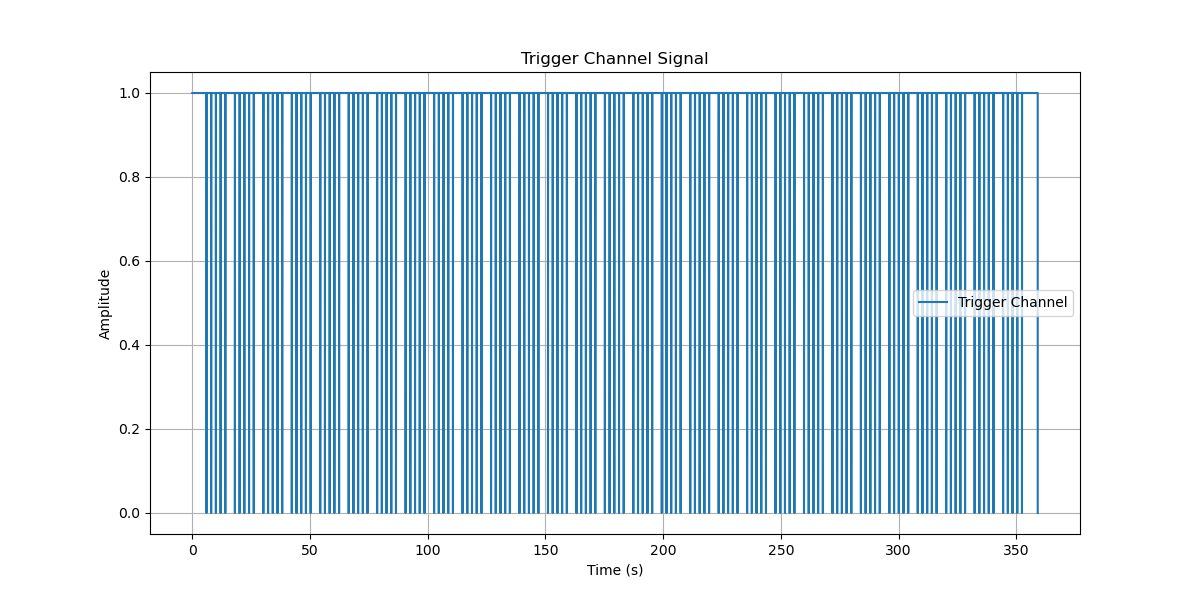

In [7]:
%matplotlib ipympl
# Plotting the trigger channel
plt.figure(figsize=(12, 6)) 
plt.plot(time_axis, trigger_samples[0], label='Trigger Channel')
plt.title('Trigger Channel Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()




In [8]:
# Find falling edges for all selected flexion files
trigger = samples[72, :]

# Find falling edges
falling_edges = np.where(np.diff(trigger) < -0.5)[0] + 1  # +1 to get the index after the transition
print(f"\nFile: {os.path.basename(file_path)}")
print("Indices where trigger goes from 1 to 0:", falling_edges)

    # Time between each trigger (in seconds)
falling_times = time_axis[falling_edges]
intervals = np.diff(falling_times)
print("Time between each trigger (s):", intervals)


File: Trial_4-20250627T145057.DATA.Poly5
Indices where trigger goes from 1 to 0: [ 12043  16047  20052  24058  28063  36210  40215  44221  48225  52231
  60380  64385  68390  72395  76400  84552  88557  92562  96567 100572
 108705 112710 116715 120720 124725 132891 136896 140901 144906 148911
 157042 161046 165051 169057 173061 181231 185237 189242 193247 197252
 205434 209439 213444 217449 221454 229633 233639 237644 241649 245654
 253813 257818 261823 265828 269834 278006 282011 286016 290021 294026
 302191 306197 310202 314207 318212 326379 330384 334389 338394 342399
 350520 354525 358530 362535 366540 374680 378685 382690 386695 390700
 398862 402867 406872 410877 414882 423040 427045 431050 435055 439060
 447206 451212 455216 459222 463227 471369 475374 479379 483385 487389
 495506 499511 503516 507521 511526 519690 523695 527700 531705 535710
 543866 547871 551876 555881 559886 568032 572038 576042 580048 584053
 592210 596215 600220 604225 608231 616328 620333 624338 628343 63

In [ ]:
selected_channels = [2,3,5]  # the EMG channel indices you care about

for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples     = reader.samples          # shape: (n_channels, n_samples)
    sample_rate = reader.sample_rate

    # split out trigger & EMG
    trigger = samples[73, :]              # your digital trigger channel
    emg     = samples[1:65, :].astype(float)  # EMG as float for interpolation

    # 1) detect rising‐edge onsets in the trigger
    #    Adjust the threshold if your trigger amplitude changes
    trig_diff = np.diff(trigger)
    onsets    = np.where(trig_diff > 0.5)[0] + 1

    # 2) build a mask of samples to remove around each spike
    #    here we remove 1 sample before and after the detected peak
    mask = np.zeros(emg.shape[1], dtype=bool)
    for idx in onsets:
        # define window of samples to mask
        start = max(idx - 1, 0)
        end   = min(idx +1, emg.shape[1])  # +2 because slice end is exclusive
        mask[start:end] = True

    # 3) interpolate each channel over the masked samples
    emg_clean = np.zeros_like(emg)
    x = np.arange(emg.shape[1])
    valid = ~mask
    for ch in range(emg.shape[0]):
        y = emg[ch].copy()
        # set spike samples to NaN
        y[mask] = np.nan
        # linear interpolate over NaNs
        emg_clean[ch] = np.interp(x, x[valid], y[valid])

    # now emg_clean has the spike artifacts removed
    # you can plot it or feed it into your bandpass / smoothing pipeline

    # --- quick plot to check channel 35 before & after ---
    import matplotlib.pyplot as plt
    t = x / sample_rate
    plt.figure(figsize=(12,3))
    plt.plot(t, emg[35],    label='raw ch35', alpha=0.5)
    plt.plot(t, emg_clean[35], label='cleaned ch35', linewidth=1)
    plt.legend()
    plt.xlabel('Time (s)'); plt.ylabel('µV')
    plt.title(f"Artifact removal check — {os.path.basename(file_path)}")
    plt.show()

    # …then continue with your usual bandpass, RMS, etc., on emg_clean


Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627-Recruitment Curve Data/Trial_4-20250627T145057.DATA.Poly5
	 Number of samples:  718254 
	 Number of channels:  75 
	 Sample rate: 2000 Hz
Done reading data.


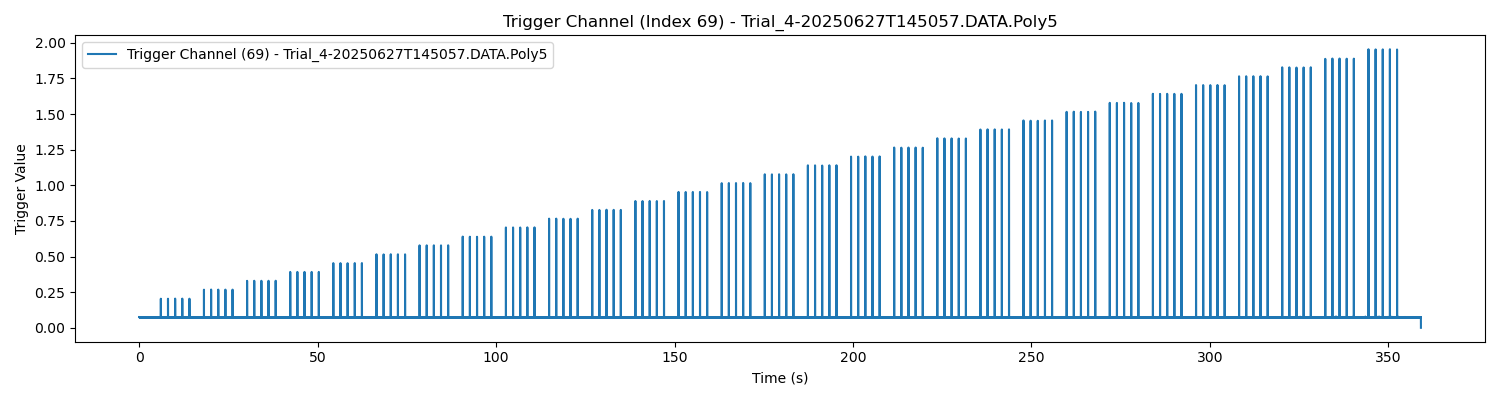

In [10]:
for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    sample_rate = reader.sample_rate
    time_axis = np.arange(samples.shape[1]) / sample_rate
    aux = samples[69, :] #nice

    plt.figure(figsize=(15, 4))
    plt.plot(time_axis, aux, label=f"Trigger Channel (69) - {os.path.basename(file_path)}")
    plt.xlabel("Time (s)")
    plt.ylabel("Trigger Value")
    plt.title(f"Trigger Channel (Index 69) - {os.path.basename(file_path)}")
    plt.legend()
    plt.tight_layout()
    plt.show()

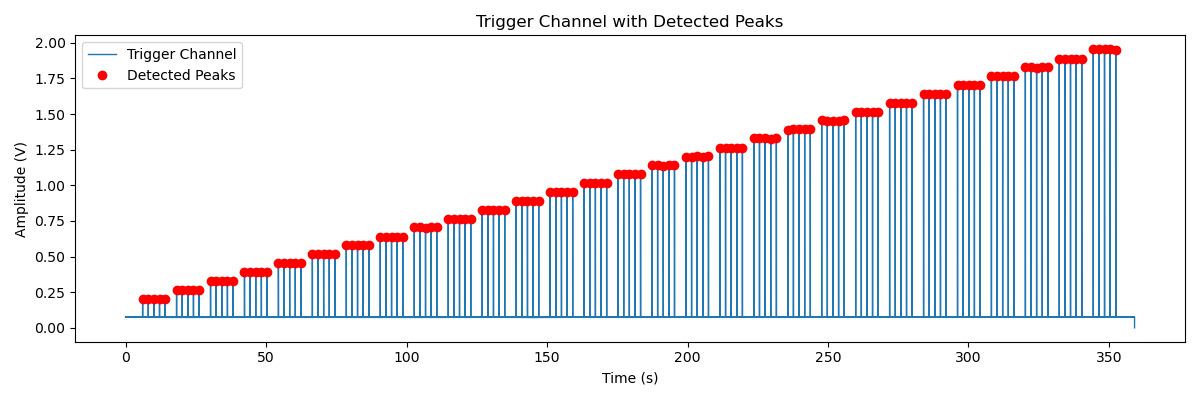

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# — your existing variables —
# aux         : 1D numpy array of your analog trigger channel
# sample_rate : sampling frequency in Hz

# 1) Detect peaks
min_height    = 0.2                              # adjust just below your smallest pulse amplitude
min_dist_samps = int(0.005 * sample_rate)        # enforce ≥5 ms between detections
peaks, props  = find_peaks(aux,
                           height=min_height,
                           distance=min_dist_samps)

# 2) Build a time axis
time_axis = np.arange(aux.size) / sample_rate

# 3) Plot the trigger channel and overlay detected peaks
plt.figure(figsize=(12, 4))
plt.plot(time_axis, aux, label='Trigger Channel', linewidth=1)
plt.plot(time_axis[peaks], aux[peaks], 'ro', label='Detected Peaks', markersize=6)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (V)')
plt.title('Trigger Channel with Detected Peaks')
plt.legend()
plt.tight_layout()
plt.show()


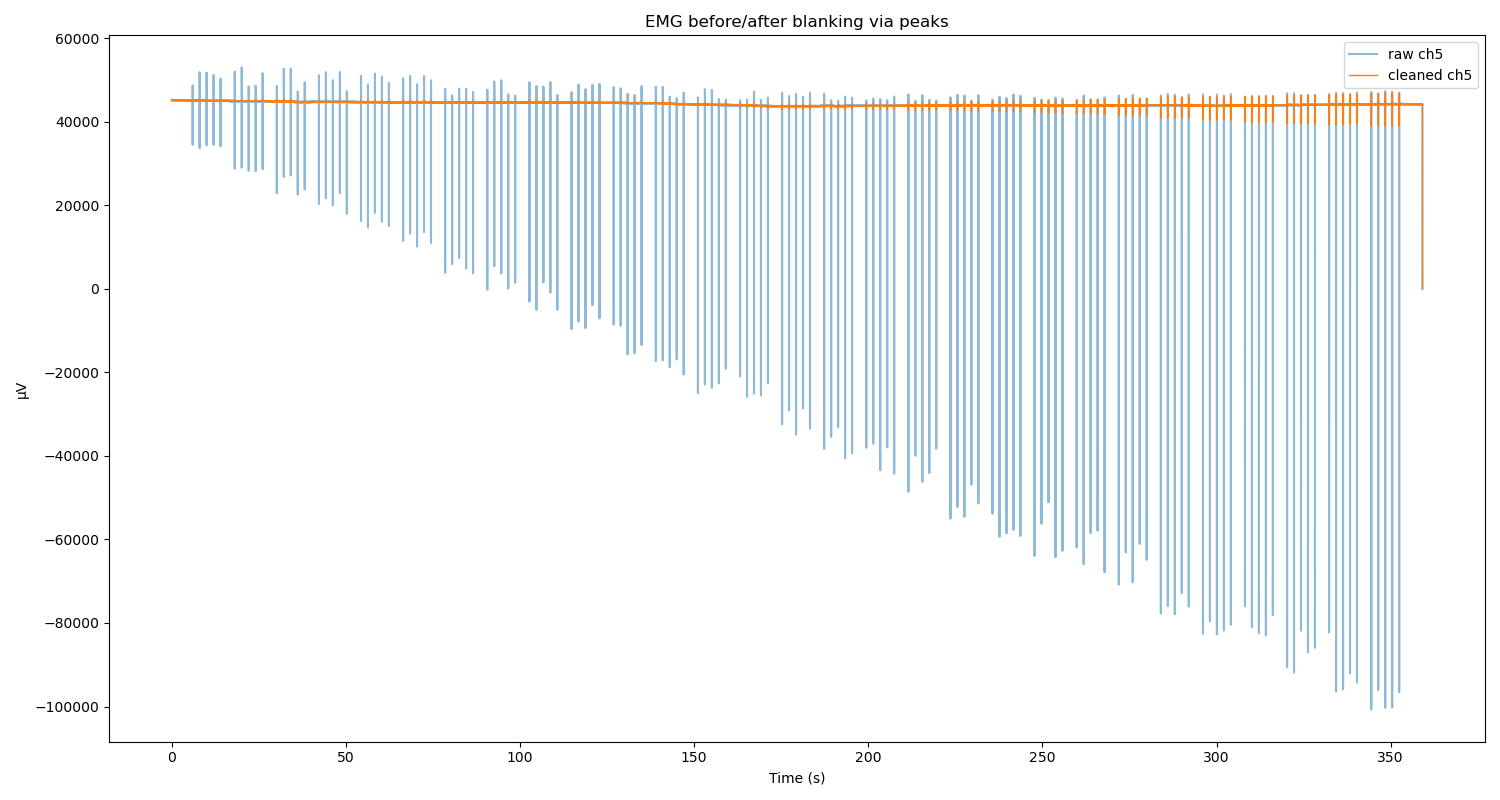

In [12]:
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# assuming I have already defined below
# samples      : raw data array, shape (n_channels, n_samples)
# sample_rate  : in Hz
emg = samples[1:65, :].astype(float)   # your EMG channels
aux = samples[69, :]                   # your analog trigger channel
n_samps = emg.shape[1]

# 1) detect peaks on trigger channel (Aux 69)
min_height    = 0.20                              # adjust to just below smallest pulse
min_dist_samps = int(0.005 * sample_rate)        # enforce ≥5 ms between detections
peaks, props  = find_peaks(aux, height=min_height, distance=min_dist_samps)


# 2) build a boolean mask around each peak
pre_ms, post_ms = 2, 2.5                      # blank 0.5 ms before to 2.5 ms after each peak
pre_samps  = int(pre_ms  * sample_rate / 1000)
post_samps = int(post_ms * sample_rate / 1000)

mask = np.zeros(n_samps, dtype=bool)
for pk in peaks:
    start = max(pk - pre_samps, 0)
    end   = min(pk + post_samps, n_samps)
    mask[start:end] = True

# 3) interpolate each EMG channel across masked samples
x     = np.arange(n_samps)
valid = ~mask
emg_clean = np.zeros_like(emg)

for ch in range(emg.shape[0]):
    y = emg[ch].copy()
    y[mask] = np.nan
    # linear interp over the NaNs
    emg_clean[ch] = np.interp(x, x[valid], y[valid])



# 4) quick plot to verify on, say, channel 5
t = np.arange(n_samps) / sample_rate
plt.figure(figsize=(15,8))
plt.plot(t, emg[5],      label='raw ch5',    alpha=0.5)
plt.plot(t, emg_clean[5], label='cleaned ch5', lw=1)
plt.xlabel('Time (s)')
plt.ylabel('µV')
plt.title('EMG before/after blanking via peaks')
plt.legend()
plt.tight_layout()
plt.show()


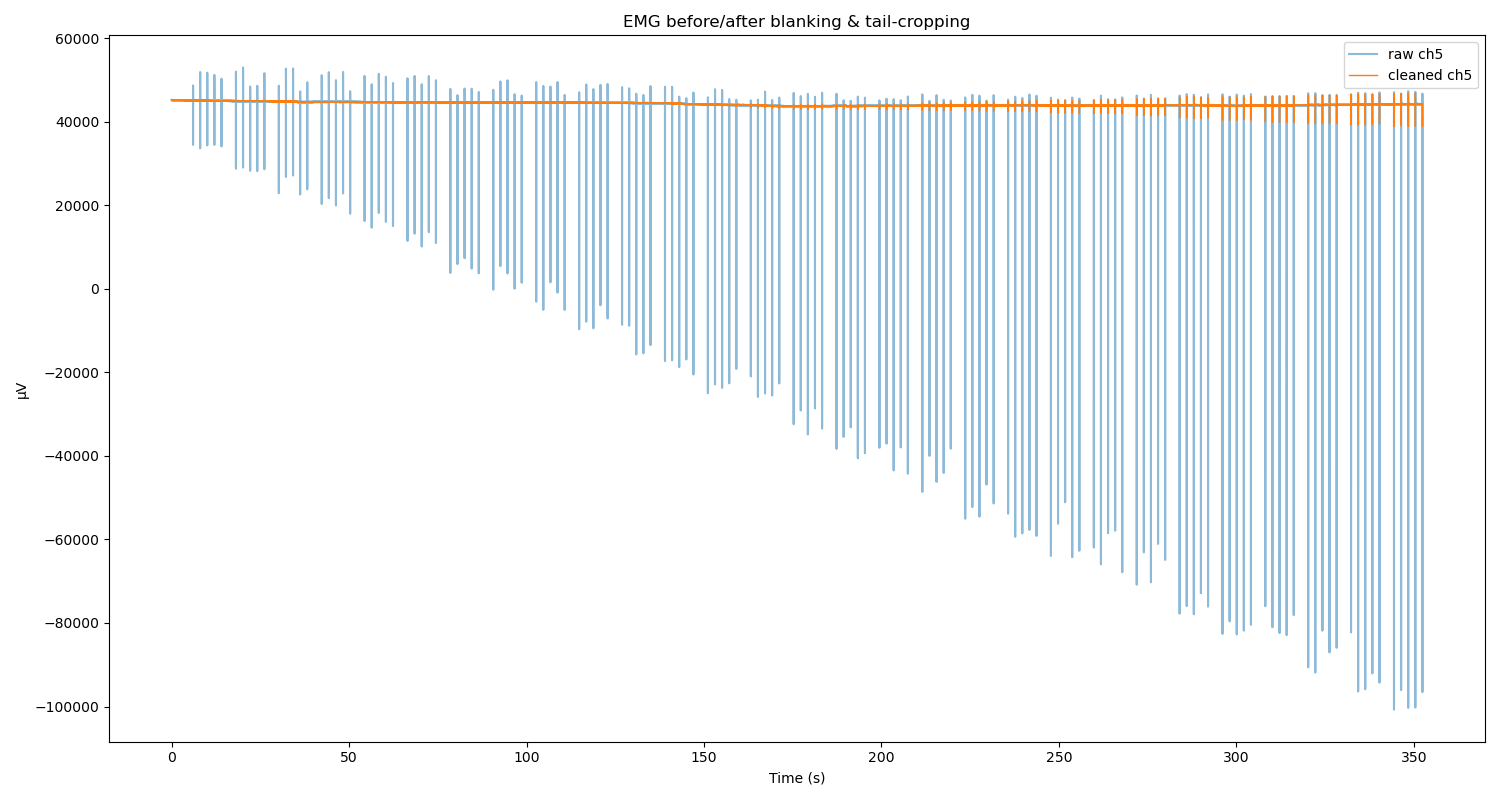

In [ ]:
#true emg clean with cropped last burst
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# assuming I have already defined below
# samples      : raw data array, shape (n_channels, n_samples)
# sample_rate  : in Hz

# 0) extract data
emg      = samples[1:65, :].astype(float)   # EMG channels
aux      = samples[69, :]                   # analog trigger channel
n_samps  = emg.shape[1]

# 1) detect peaks on trigger channel
min_height     = 0.20                              # adjust to just below smallest pulse
min_dist_samps = int(0.005 * sample_rate)          # enforce ≥5 ms between detections
peaks, props   = find_peaks(aux,
                           height=min_height,
                           distance=min_dist_samps)

# 2) build a boolean mask around each peak
pre_ms, post_ms = 2, 5                           # ms before/after each peak to blank
pre_samps   = int(pre_ms  * sample_rate / 1000)
post_samps  = int(post_ms * sample_rate / 1000)

mask = np.zeros(n_samps, dtype=bool)
for pk in peaks:
    start = max(pk - pre_samps, 0)
    end   = min(pk + post_samps, n_samps)
    mask[start:end] = True

# 3) interpolate each EMG channel across masked samples
x       = np.arange(n_samps)
valid   = ~mask
emg_clean = np.zeros_like(emg)
for ch in range(emg.shape[0]):
    y = emg[ch].copy()
    y[mask] = np.nan
    emg_clean[ch] = np.interp(x, x[valid], y[valid])

# 
# 4) cropping last burst after last trigger
buffer_ms    = 10                                  # e.g. drop last 10 ms of recording
buffer_samps = int(buffer_ms * sample_rate / 1000)
last_pk      = peaks[-1]
end_idx      = min(last_pk + buffer_samps, n_samps)

# slice EMG and time‐axis
emg        = emg[:, :end_idx]
emg_clean  = emg_clean[:, :end_idx]
t          = np.arange(end_idx) / sample_rate

# 5) quick plot to verify on channel 5
plt.figure(figsize=(15, 8))
plt.plot(t, emg[5],       label='raw ch5',    alpha=0.5)
plt.plot(t, emg_clean[5], label='cleaned ch5', lw=1)
plt.xlabel('Time (s)')
plt.ylabel('µV')
plt.title('EMG before/after blanking & tail-cropping')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(15, 8))
plt.plot(t, emg_clean[5], label='cleaned ch5', lw=1)

In [14]:
def butter_highpass(cutoff, fs, order=4):
    nyq = fs / 2.0
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return b, a
def highpass_filter(data, cutoff, fs, order=4):
    b, a = butter_highpass(cutoff, fs, order=order)
    return filtfilt(b, a, data, axis=1)  # apply along time axis (axis=1)
    
hp_cutoff = 10 #(Hz)
emg_h = highpass_filter(emg_clean, hp_cutoff, sample_rate, order = 4 )

next to do is down below!

60hz notch filter not necessary, double differentiation was fine with a -2 to 5ms timing pre and post for blanking, spatial filters (60hz) could be added later to help identify h-reflex waves

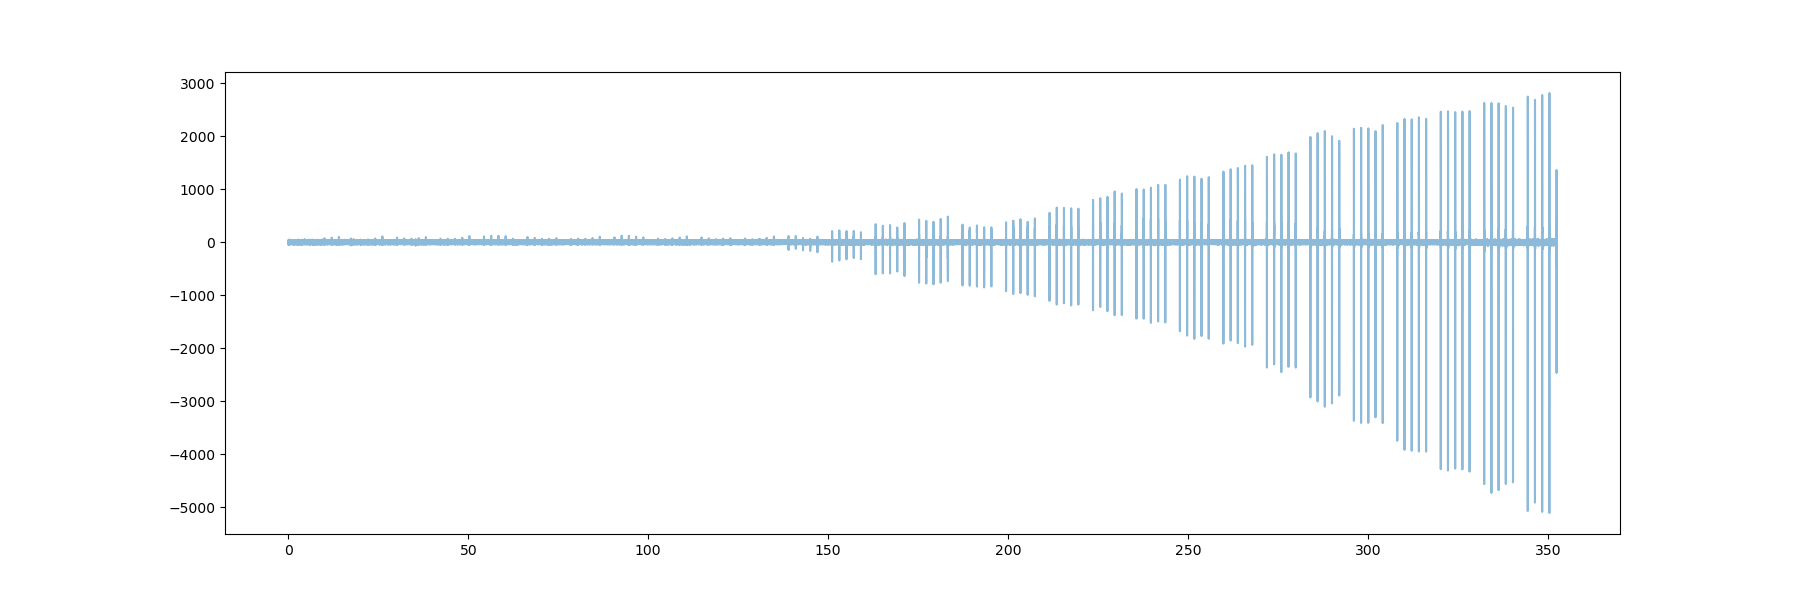

In [15]:
#60hz notch filter implement? or differentiating instead of notch filtering, rms not necessary, differentiating over longways across arm length not wide
plt.figure(figsize=(18, 6))
plt.plot(t, emg_h[5], label='Cleaned EMG (baseline-corrected) wth __hz highpass', alpha=0.5)

In [ ]:
#RMS? not necessary rn
import numpy as np
from scipy.ndimage import uniform_filter1d


window_ms   = 50                           # RMS window in milliseconds
window_samps = int(window_ms * sample_rate / 1000)

# 2) square the signal
emg2 = emg_h**2

# 3) compute the moving average of the squared signal
#    along the time axis = 1
#    mode='reflect' avoids edge artifacts
mean_sq = uniform_filter1d(emg2,
                           size=window_samps,
                           axis=1,
                           mode='reflect')

# 4) take the square-root to get the RMS
emg_rms = np.sqrt(mean_sq)

# emg_rms now has the same shape as emg_h, and each point
# is the RMS over ±window_ms/2 (effectively a causal window).

# --- optional plot for one channel ---
import matplotlib.pyplot as plt
t = np.arange(emg_h.shape[1]) / sample_rate

plt.figure(figsize=(10,4))
plt.plot(t, emg_h[0],    label='High-passed EMG (ch 0)', alpha=0.5)
plt.plot(t, emg_rms[0],  label='RMS 50 ms (ch 0)',      linewidth=1.5)
plt.xlabel('Time (s)')
plt.ylabel('µV')
plt.title('EMG RMS Envelope (50 ms window)')
plt.legend()
plt.tight_layout()
plt.show()


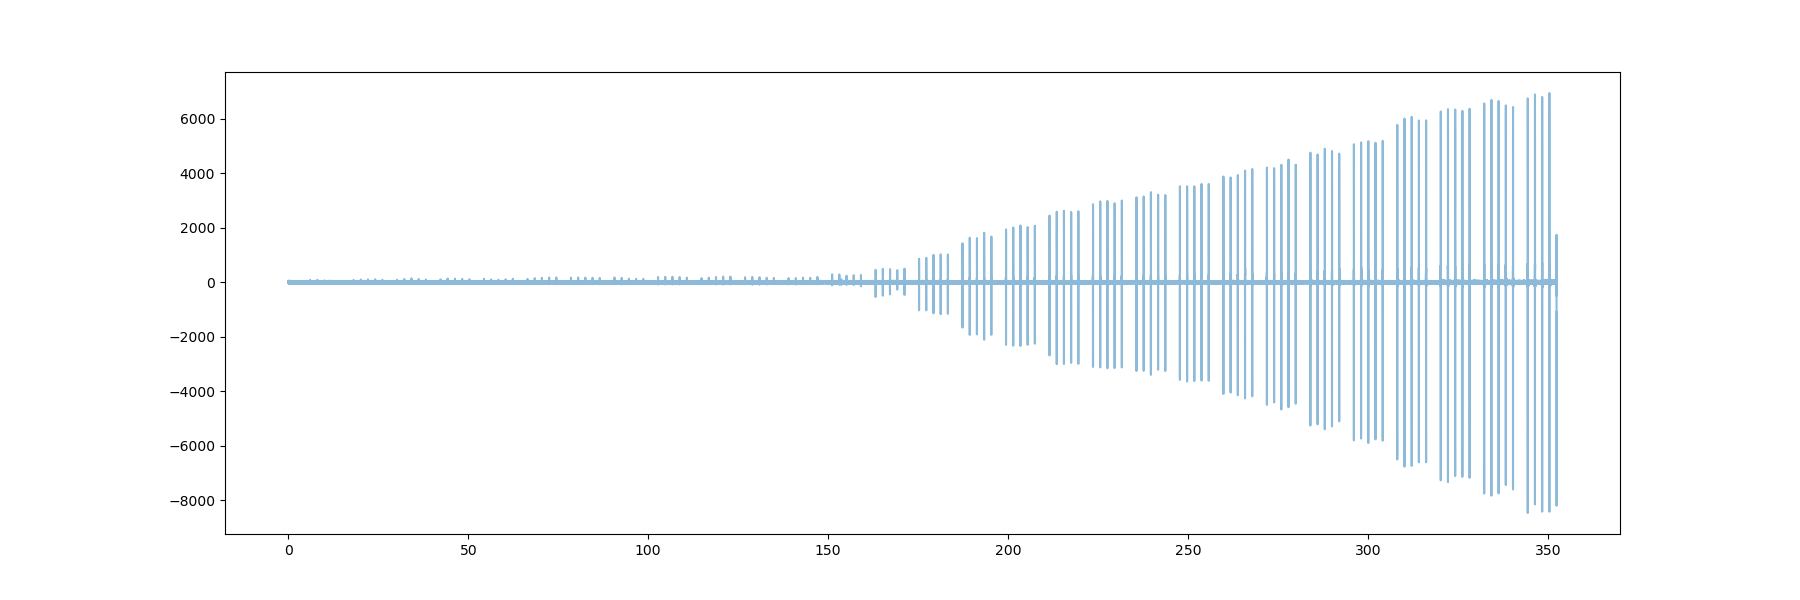

In [16]:
import numpy as np

# emg_h: your high-passed EMG, shape (n_ch, n_samps)
# sample_rate: your Fs

# 1) define your channel triplets as (left, center, right)
#    e.g. if you want DD of channels 4–5–6 and 12–13–14:
neighbor_sets = [
    17, 22, 27, 32, 33, 38, 43, 48
    # …add more triplets here…
]
neighbor_emg = emg_h[neighbor_sets, :]
emg_1d = np.diff(neighbor_emg, axis=0)
emg_2d = np.diff(emg_1d, axis=0)
n_samps = emg_h.shape[1]
n_sets   = len(neighbor_sets)

# # 2) allocate output: one DD trace per triplet
# emg_dd = np.zeros((n_sets, n_samps))

# # 3) compute second difference for each set
# for i, (l, c, r) in enumerate(neighbor_sets):
#     emg_dd[i, :] = ( emg_h[l, :]
#                     - 2*emg_h[c, :]
#                     +    emg_h[r, :] )

# # now emg_dd[0] is the DD of channels 4,5,6; emg_dd[1] is 12,13,14; etc.
plt.figure(figsize=(18, 6))
plt.plot(t, emg_2d[0], label='Second Difference of Channels 17, 22, 27', alpha=0.5) 

In [17]:

def trigger_peaks_to_current(trigger, 
                             fs=None, 
                             height=None, 
                             distance=None):
    """
   Find peaks and convert to current shawww
    trigger : array-like
        1D trigger channel (voltages).
    fs : float, optional
        Sampling rate (Hz). If provided, will also return times in seconds.
    height : float or tuple, optional
        Passed to scipy.signal.find_peaks to threshold peak heights.
    distance : int, optional
        Passed to scipy.signal.find_peaks to impose a minimum sample 
        distance between peaks.

    
    peaks_idx : ndarray
        Sample indices of each detected peak.
    times_s : ndarray or None
        Time of each peak in seconds (if fs given), else None.
    volts   : ndarray
        Voltage of each peak.
    currents_mA : ndarray
        Converted current for each peak, in mA.
    """
    # 1) find local maxima in the trigger waveform
    peaks_idx, props = find_peaks(trigger, height=height, distance=distance)

    # 2) peak voltages
    volts = trigger[peaks_idx]

    # 3) apply conversion: 80 mA per 10 V => 8 mA/V
    currents_mA = (80 / 10) * volts

    # optional time vector
    times_s = peaks_idx / fs if fs is not None else None

    return peaks_idx, times_s, volts, currents_mA


# assume `trigger` is your NumPy array and sample_rate is in Hz
idx, t_peak, v_peak, i_peak = trigger_peaks_to_current(
    aux,
    fs=sample_rate,
    height=0.1,     # e.g. only detect peaks above 0.1 V
    distance=100    # e.g. at least 100 samples between peaks
)

for k, (vv, ii) in enumerate(zip(v_peak, i_peak)):
    print(f"Peak #{k:2d}: {vv:.3f} V  →  {ii:.2f} mA")

Peak # 0: 0.204 V  →  1.63 mA
Peak # 1: 0.204 V  →  1.63 mA
Peak # 2: 0.205 V  →  1.64 mA
Peak # 3: 0.205 V  →  1.64 mA
Peak # 4: 0.204 V  →  1.63 mA
Peak # 5: 0.267 V  →  2.14 mA
Peak # 6: 0.268 V  →  2.15 mA
Peak # 7: 0.268 V  →  2.14 mA
Peak # 8: 0.268 V  →  2.14 mA
Peak # 9: 0.268 V  →  2.14 mA
Peak #10: 0.329 V  →  2.64 mA
Peak #11: 0.330 V  →  2.64 mA
Peak #12: 0.330 V  →  2.64 mA
Peak #13: 0.330 V  →  2.64 mA
Peak #14: 0.330 V  →  2.64 mA
Peak #15: 0.392 V  →  3.14 mA
Peak #16: 0.392 V  →  3.14 mA
Peak #17: 0.392 V  →  3.14 mA
Peak #18: 0.392 V  →  3.14 mA
Peak #19: 0.392 V  →  3.14 mA
Peak #20: 0.454 V  →  3.63 mA
Peak #21: 0.454 V  →  3.63 mA
Peak #22: 0.453 V  →  3.63 mA
Peak #23: 0.454 V  →  3.63 mA
Peak #24: 0.454 V  →  3.63 mA
Peak #25: 0.516 V  →  4.13 mA
Peak #26: 0.515 V  →  4.12 mA
Peak #27: 0.516 V  →  4.13 mA
Peak #28: 0.516 V  →  4.13 mA
Peak #29: 0.515 V  →  4.12 mA
Peak #30: 0.579 V  →  4.63 mA
Peak #31: 0.579 V  →  4.63 mA
Peak #32: 0.579 V  →  4.63 mA
Peak #33: 

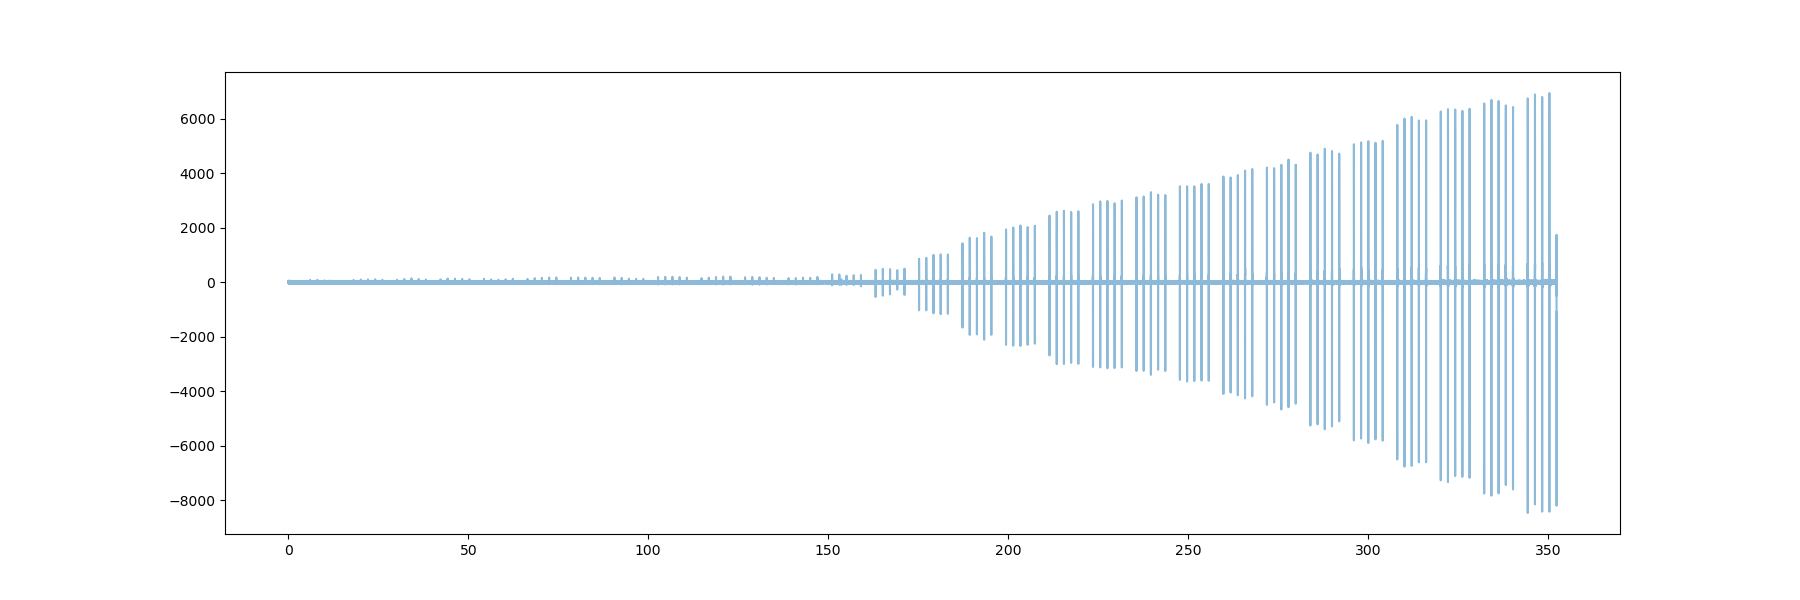

In [18]:
import numpy as np

# emg_h: your high-passed EMG, shape (n_ch, n_samps)
# sample_rate: your Fs

# 1) define your channel triplets as (left, center, right)
#    e.g. if you want DD of channels 4–5–6 and 12–13–14:
neighbor_sets = [
    17, 22, 27, 32, 33, 38, 43, 48
    
]
neighbor_triplets = [
    tuple(neighbor_sets[i : i + 3])
    for i in range(len(neighbor_sets) - 2)
]

neighbor_emg = emg_h[neighbor_sets, :]
emg_1d = np.diff(neighbor_emg, axis=0)
emg_2d = np.diff(emg_1d, axis=0)
n_samps = emg_h.shape[1]
n_sets   = len(neighbor_sets)

# # 2) allocate output: one DD trace per triplet
# emg_dd = np.zeros((n_sets, n_samps))

# # 3) compute second difference for each set
# for i, (l, c, r) in enumerate(neighbor_sets):
#     emg_dd[i, :] = ( emg_h[l, :]
#                     - 2*emg_h[c, :]
#                     +    emg_h[r, :] )

# # now emg_dd[0] is the DD of channels 4,5,6; emg_dd[1] is 12,13,14; etc.
plt.figure(figsize=(18, 6))
plt.plot(t, emg_2d[0], label='Second Difference of Channels 17, 22, 27', alpha=0.5) 

In [19]:
#KEY TO KNOW WHICH NEIGHBOR TRIPLETS I AM CALLING FROM THE P2P CALCULATION BELOW
print(neighbor_triplets)
ch_idx = 2
print(f"Row {ch_idx} of emg_2d corresponds to electrodes {neighbor_triplets[ch_idx]}")
# → Row 2 of emg_2d corresponds to electrodes (27, 32, 33)


[(17, 22, 27), (22, 27, 32), (27, 32, 33), (32, 33, 38), (33, 38, 43), (38, 43, 48)]
Row 2 of emg_2d corresponds to electrodes (27, 32, 33)


In [20]:
import numpy as np
from scipy.signal import find_peaks

# ─── 1. Your window definitions ───────────────────────────────────────────────
m_window_ms = (6, 10)    # M-wave window in ms
h_window_ms = (25, 35)   # H-wave window in ms

m_window_samples = (
    int(m_window_ms[0] * sample_rate / 1000),
    int(m_window_ms[1] * sample_rate / 1000)
)
h_window_samples = (
    int(h_window_ms[0] * sample_rate / 1000),
    int(h_window_ms[1] * sample_rate / 1000)
)

# ─── 2. Detect trigger peaks ─────────────────────────────────────────────────
peaks_idx, times_s, v_peaks, i_peaks = trigger_peaks_to_current(
    aux, fs=sample_rate, height=0.1, distance=100
)

# ─── 3. Filter out any peaks too close to the start or end ───────────────────
n_samples = emg_2d.shape[1]
valid_mask = (
    (peaks_idx + h_window_samples[1] <= n_samples)  # fits H-window
)
peaks_idx = peaks_idx[valid_mask]

# ─── 4. Allocate storage ─────────────────────────────────────────────────────
n_channels = emg_2d.shape[0]
n_peaks    = len(peaks_idx)
m_ptp = np.zeros((n_peaks, n_channels))
h_ptp = np.zeros((n_peaks, n_channels))

# ─── 5. Loop & compute ptp ───────────────────────────────────────────────────
for i, pk in enumerate(peaks_idx):
    m_start, m_end = pk + m_window_samples[0], pk + m_window_samples[1]
    h_start, h_end = pk + h_window_samples[0], pk + h_window_samples[1]
    
    for ch in range(n_channels):
        seg_m = emg_2d[ch, m_start:m_end]
        seg_h = emg_2d[ch, h_start:h_end]
        m_ptp[i, ch] = np.ptp(seg_m)
        h_ptp[i, ch] = np.ptp(seg_h)

# ─── 6. Average if desired ───────────────────────────────────────────────────
m_ptp_mean = m_ptp.mean(axis=0)
h_ptp_mean = h_ptp.mean(axis=0)

# ─── 7. Example print for channel 37 ────────────────────────────────────────
ch_idx = 0
print(f"Ch {ch_idx} M-ptp (mean): {m_ptp_mean[ch_idx]:.2f}")
print(f"Ch {ch_idx} H-ptp (mean): {h_ptp_mean[ch_idx]:.2f}")




Ch 0 M-ptp (mean): 2373.73
Ch 0 H-ptp (mean): 231.79


In [ ]:
#checks and balances for edge peaks in M- and H-wave windows
import numpy as np

def check_edge_peaks(emg_dd, peaks_idx, m_win, h_win):
    """
    emg_dd:    double-differentiated EMG, shape (n_ch, n_samps)
    peaks_idx: array of stim indices
    m_win:     (m_start, m_end) in samples relative to each peak
    h_win:     (h_start, h_end) in samples relative to each peak
    """
    edge_flags = {'M': [], 'H': []}

    for i, pk in enumerate(peaks_idx):
        for name, (w0, w1) in (('M', m_win), ('H', h_win)):
            seg = emg_dd[:, pk + w0 : pk + w1]  # shape (n_ch, win_len)
            # for each channel, did max or min occur at either edge?
            max_at_start = (seg.argmax(axis=1) == 0)
            max_at_end   = (seg.argmax(axis=1) == seg.shape[1]-1)
            min_at_start = (seg.argmin(axis=1) == 0)
            min_at_end   = (seg.argmin(axis=1) == seg.shape[1]-1)
            # if any channel has an edge peak, flag it
            if max_at_start.any() or max_at_end.any() or min_at_start.any() or min_at_end.any():
                edge_flags[name].append(i)

    return edge_flags

# usage, after you’ve built `peaks_idx` and `emg_2d`:
flags = check_edge_peaks(
    emg_2d,
    peaks_idx,
    m_window_samples,
    h_window_samples
)
print("M-wave windows clipping at edges on snippets:", flags['M'])
print("H-wave windows clipping at edges on snippets:", flags['H'])


In [ ]:
#checking for edge peaks in M- and H-wave windows to make sure they are coming in correctly
# convert sample‐relative peak positions into ms
ptp_lats = {'M': [], 'H': []}

for name, (w0, w1), ptp_arr in (
    ('M', m_window_samples, m_ptp),
    ('H', h_window_samples, h_ptp)
):
    lats = []
    for i, pk in enumerate(peaks_idx):
        # Re-extract that segment
        seg = emg_2d[:, pk + w0 : pk + w1]
        # for a given channel you care about (e.g. ch_idx=2):
        ch_idx = 2
        rel_idx = seg[ch_idx].argmax() if name=='M' else seg[ch_idx].argmin()
        lat_ms = (w0 + rel_idx) * 1000. / sample_rate
        lats.append(lat_ms)
    ptp_lats[name] = np.array(lats)

print("M-wave latencies (ms):", ptp_lats['M'])
print("H-wave latencies (ms):", ptp_lats['H'])
print("M mean:", ptp_lats['M'].mean(), "H mean:", ptp_lats['H'].mean())


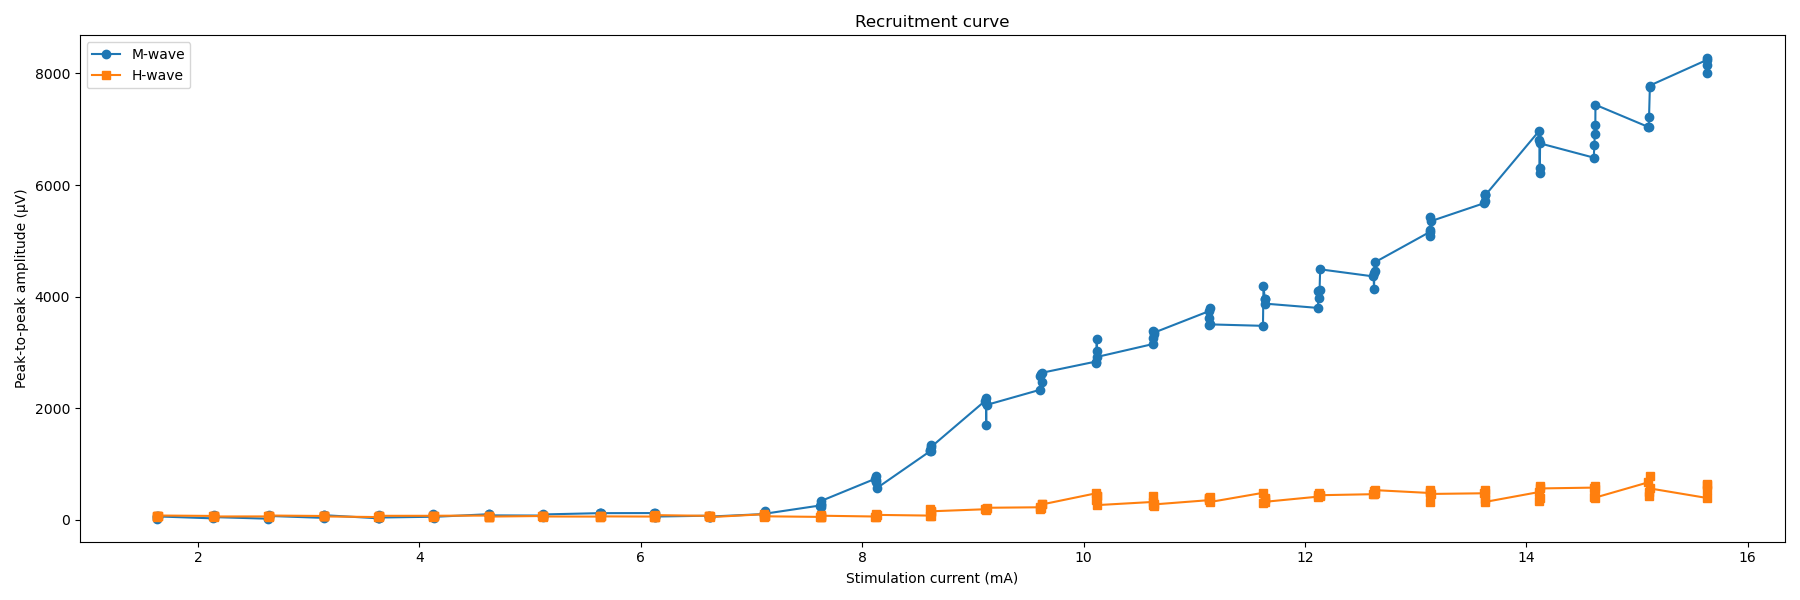

In [ ]:
ch_idx_dd = 0
#  After detecting all peaks 
peaks_idx, times_s, v_peaks, i_peaks = trigger_peaks_to_current(
    aux, fs=sample_rate, height=0.1, distance=100
)

#  Filter out edge‐of‐recording peaks 
n_samples = emg_2d.shape[1]
valid_mask = (peaks_idx + h_window_samples[1] <= n_samples)
peaks_idx = peaks_idx[valid_mask]
times_s    = times_s[valid_mask]    if times_s is not None else None
v_peaks    = v_peaks[valid_mask]
i_peaks    = i_peaks[valid_mask]

# Assumign I built my m_ptp and h_ptp arrays for exactly these peaks


# sort by the filtered currents 
order           = np.argsort(i_peaks)            # now length == n_peaks
currents_sorted = i_peaks[order]
m_sorted        = m_ptp[:, ch_idx_dd][order]
h_sorted        = h_ptp[:, ch_idx_dd][order]


plt.figure(figsize=(18,6))
plt.clf()      # clear anything from a prior cell/figure (idk it was plotting for some reason)
plt.plot(currents_sorted, m_sorted, 'o-', label='M-wave')
plt.plot(currents_sorted, h_sorted, 's-', label='H-wave')
plt.xlabel('Stimulation current (mA)')
plt.ylabel('Peak-to-peak amplitude (µV)')
plt.title('Recruitment curve')
plt.legend()
plt.tight_layout()
plt.show()



ERNESTO SUGGESTION:"I usually plot the time series of each evoked response using an 8×8 grid of subplots per intensity, with each intensity shown in a separate figure. For each plot, I zoom in on the 0 to 30 ms window. By examining the time series, you can estimate the peak-to-peak amplitude by comparing the y-axis values with those obtained using the peak2peak function."
waterfall plot (200 difference) before and after 1 for every montage (groups of 3)
look into single differential 1d
look for h-waves @ higher amplitudes in the other data (10hz)

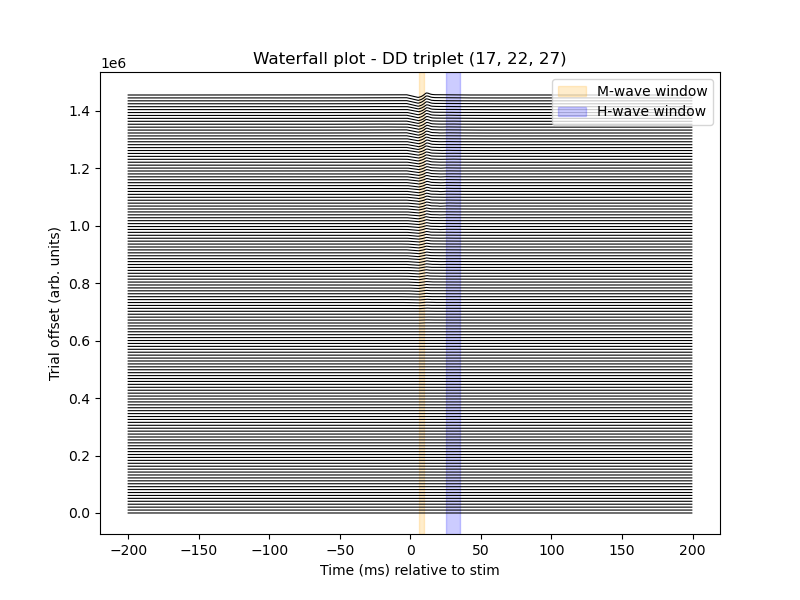

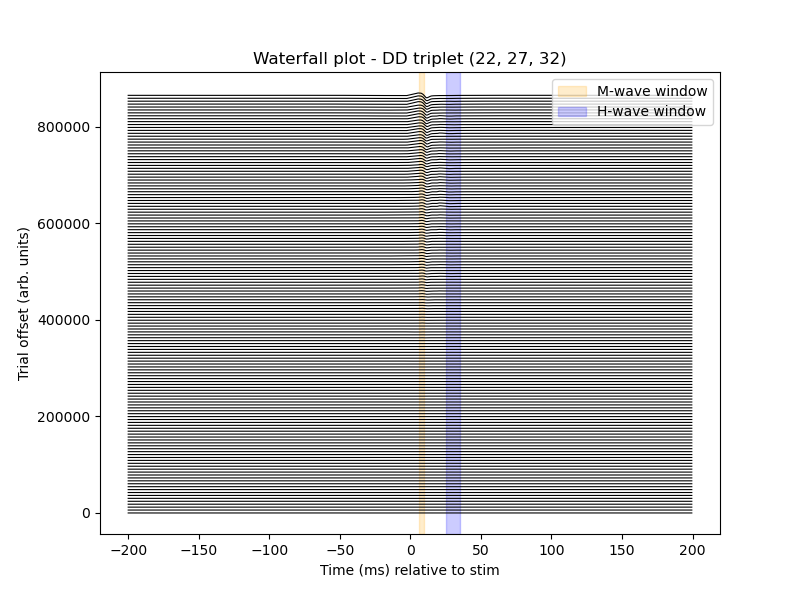

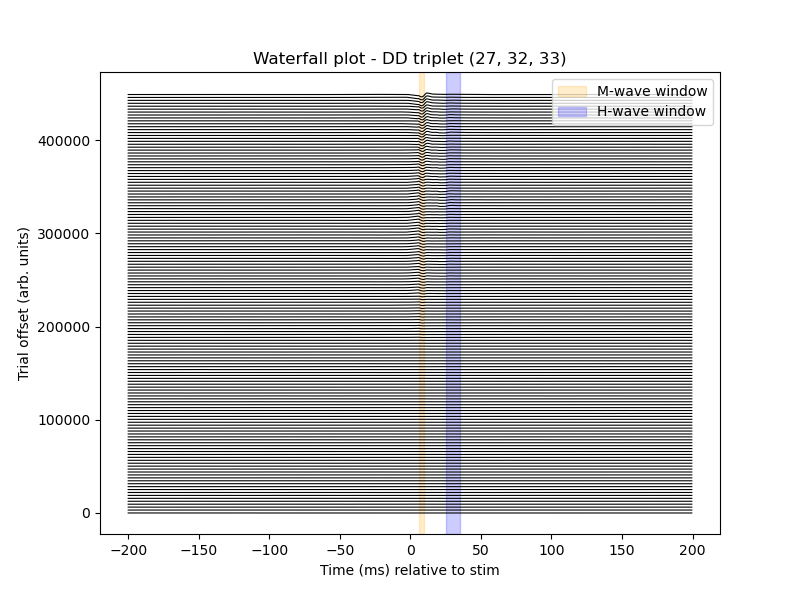

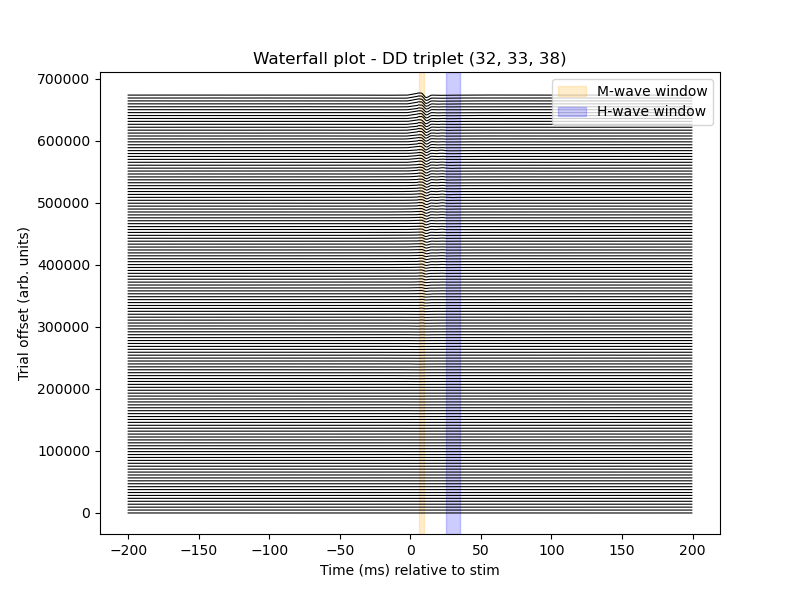

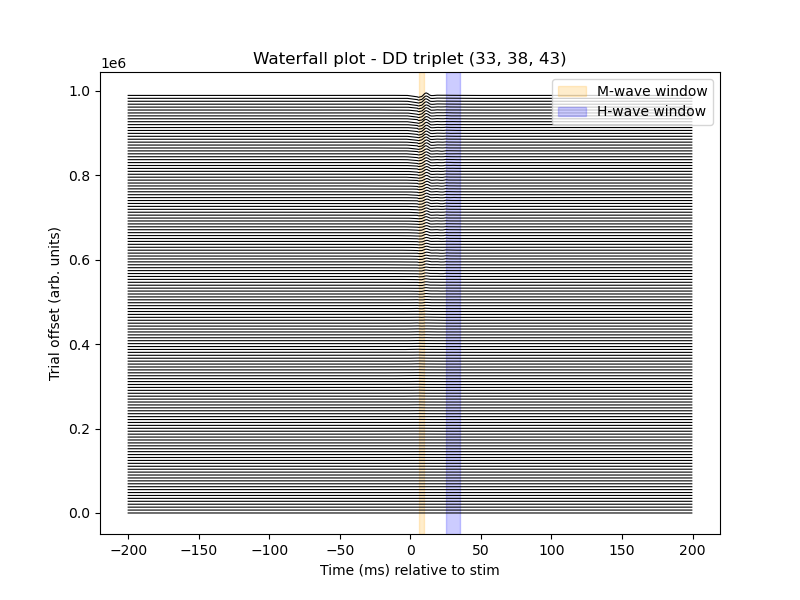

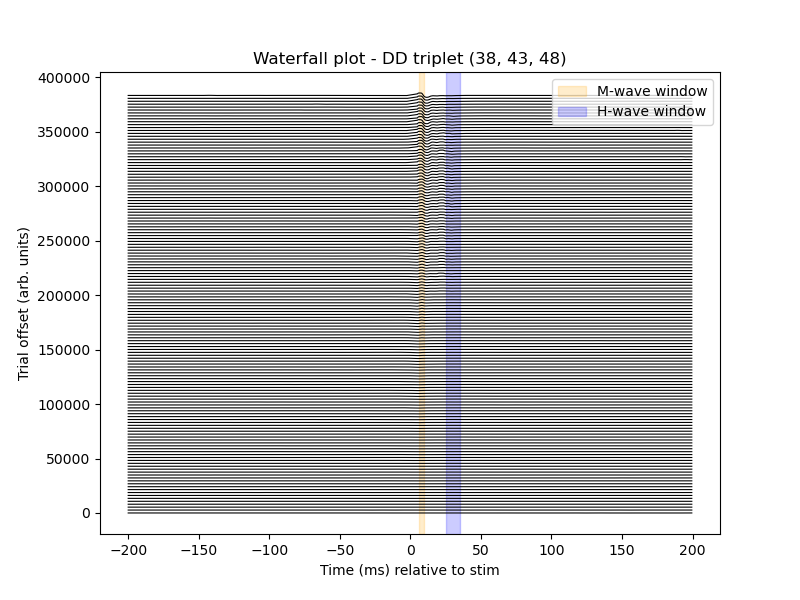

In [26]:

# --- Parameters ---
pre_ms  = 200   # ms before stim
post_ms = 200   # ms after stim

pre_samps  = int(pre_ms  * sample_rate / 1000)
post_samps = int(post_ms * sample_rate / 1000)

# Time axis for plotting (stim at 0 ms)
time_axis = np.arange(-pre_samps, post_samps) / sample_rate * 1000  # ms

# Convert M/H windows from samples to ms directly
m_start_ms = m_window_samples[0] * 1000 / sample_rate
m_end_ms   = m_window_samples[1] * 1000 / sample_rate
h_start_ms = h_window_samples[0] * 1000 / sample_rate
h_end_ms   = h_window_samples[1] * 1000 / sample_rate

# --- Loop through triplets and make waterfall plots ---
for trip_idx, triplet in enumerate(neighbor_triplets):
    # Extract all snippets for this triplet
    snippets = []
    for pk in peaks_idx:
        start = pk - pre_samps
        end   = pk + post_samps
        if start >= 0 and end <= emg_2d.shape[1]:
            snippets.append(emg_2d[trip_idx, start:end])
    snippets = np.array(snippets)  # shape: (n_trials, n_samps_window)

    # Create waterfall plot
    fig, ax = plt.subplots(figsize=(8,6))
    offset = 0
    spacing = np.max(np.abs(snippets)) * 1.2  # vertical spacing

    for snip in snippets:
        ax.plot(time_axis, snip + offset, color='k', lw=0.8)
        offset += spacing

    # Overlay M-wave and H-wave windows (stim at 0 ms)
    ax.axvspan(m_start_ms, m_end_ms, color='orange', alpha=0.2, label='M-wave window')
    ax.axvspan(h_start_ms, h_end_ms, color='blue', alpha=0.2, label='H-wave window')

    ax.set_title(f"Waterfall plot - DD triplet {triplet}")
    ax.set_xlabel("Time (ms) relative to stim")
    ax.set_ylabel("Trial offset (arb. units)")
    ax.legend(loc='upper right')
    plt.show()
